## 1. Постановка задачи

<center> <img src=https://storage.googleapis.com/kaggle-competitions/kaggle/3333/media/taxi_meter.png align="right" width="300"/> </center>
    
Вам предстоит решить настоящую задачу машинного обучения, направленную на автоматизацию бизнес процессов. Мы построим модель, которая будет предсказывать общую продолжительность поездки такси в Нью-Йорке. 

Представьте вы заказываете такси из одной точки Нью-Йорка в другую, причем не обязательно конечная точка должна находиться в пределах города. Сколько вы должны будете за нее заплатить? Известно, что стоимость такси в США  рассчитывается на основе фиксированной ставки + тарифная стоимость, величина которой зависит от времени и расстояния. Тарифы варьируются в зависимости от города.

В свою очередь время поездки зависит от множества факторов таких как, откуда и куда вы едете, в какое время суток вы совершаете вашу поездку, погодных условий и так далее. 

Таким образом, если мы разработаем алгоритм, способный определять длительность поездки, мы сможем прогнозировать ее стоимость самым тривиальным образом, например, просто умножая стоимость на заданный тариф. 
Сервисы такси хранят огромные объёмы информации о поездках, включая такие данные как конечная, начальная точка маршрута, дата поездки и ее длительность. Эти данные можно использовать для того, чтобы прогнозировать длительность поездки в автоматическом режиме с привлечением искусственного интеллекта.

**Бизнес-задача:** определить характеристики и с их помощью спрогнозировать длительность поездки такси.

**Техническая задача для вас как для специалиста в Data Science:** построить модель машинного обучения, которая на основе предложенных характеристик клиента будет предсказывать числовой признак - время поездки такси. То есть решить задачу регрессии.

**Основные цели проекта:**
1. Сформировать набор данных на основе нескольких источников информации
2. Спроектировать новые признаки с помощью Feature Engineering и выявить наиболее значимые при построении модели
3. Исследовать предоставленные данные и выявить закономерности
4. Построить несколько моделей и выбрать из них наилучшую по заданной метрике
5. Спроектировать процесс предсказания времени длительности поездки для новых данных

Загрузить свое решение на платформу Kaggle, тем самым поучаствовав в настоящем Data Science соревновании.
Во время выполнения проекта вы отработаете навыки работы с несколькими источниками данных, генерации признаков, разведывательного анализа и визуализации данных, отбора признаков и, конечно же, построения моделей машинного обучения!


## 2. Знакомство с данными, базовый анализ и расширение данных

Начнём наше исследование со знакомства с предоставленными данными. А также подгрузим дополнительные источники данных и расширим наш исходный датасет. 


Заранее импортируем модули, которые нам понадобятся для решения задачи:

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn import feature_selection

Прочитаем наш файл с исходными данными:

In [123]:
taxi_data = pd.read_csv("data/train.csv")
print('Train data shape: {}'.format(taxi_data.shape))
taxi_data.head()

Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [124]:
taxi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


Итак, у нас с вами есть данные о почти 1.5 миллионах поездок и 11 характеристиках, которые описывают каждую из поездок. 

Мы условно разделили признаки нескольких групп. Каждой из групп мы в дальнейшем уделим отдельное внимание.

**Данные о клиенте и таксопарке:**
* id - уникальный идентификатор поездки
* vendor_id - уникальный идентификатор поставщика (таксопарка), связанного с записью поездки

**Временные характеристики:**
* pickup_datetime - дата и время, когда был включен счетчик поездки
* dropoff_datetime - дата и время, когда счетчик был отключен

**Географическая информация:**
* pickup_longitude -  долгота, на которой был включен счетчик
* pickup_latitude - широта, на которой был включен счетчик
* dropoff_longitude - долгота, на которой счетчик был отключен
* dropoff_latitude - широта, на которой счетчик был отключен

**Прочие признаки:**
* passenger_count - количество пассажиров в транспортном средстве (введенное водителем значение)
* store_and_fwd_flag - флаг, который указывает, сохранилась ли запись о поездке в памяти транспортного средства перед отправкой поставщику. Y - хранить и пересылать, N - не хранить и не пересылать поездку.

**Целевой признак:**
* trip_duration - продолжительность поездки в секундах


Для начала мы проведем базовый анализ того, насколько данные готовы к дальнейшей предобработке и анализу. 

### Задание 2.1
Для начала посмотрим на временные рамки, в которых мы работаем с данными.

Переведите признак pickup_datetime в тип данных datetime с форматом год-месяц-день час:минута:секунда (в функции pd.to_datetime() параметр format='%Y-%m-%d %H:%M:%S'). 

Определите временные рамки (без учета времени), за которые представлены данные.

In [125]:
# делаем копию данных
df = taxi_data.copy()

# понижаем размерность признаков по типу занимаемых данных
df['trip_duration'] = df['trip_duration'].astype('int32')

# преобразуем признаки в формат datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], format='%Y-%m-%d %H:%M:%S')

# выводим результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(2), object(3)
memory usage: 116.9+ MB


In [126]:
# ответ на вопрос
print(f"Данные в датасете с : {df['pickup_datetime'].dt.date.min().strftime('%Y-%m-%d')}")
print(f"Данные в датасете по: {df['pickup_datetime'].dt.date.max().strftime('%Y-%m-%d')}")

Данные в датасете с : 2016-01-01
Данные в датасете по: 2016-06-30


### Задание 2.2
Посмотрим на пропуски. 
Сколько пропущенных значений присутствует в данных (суммарно по всем столбцам таблицы)?

In [127]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

### Задание 2.3
Посмотрим на статистические характеристики некоторых признаков. 

а) Сколько уникальных таксопарков присутствует в данных?

б) Каково максимальное количество пассажиров?

в) Чему равна средняя и медианная длительность поездки? Ответ приведите в секундах и округлите до целого.

г) Чему равно минимальное и максимальное время поездки (в секундах)?


In [128]:
print(f"Количество уникальных таксопарков: {df['vendor_id'].nunique()}")

print(f"Максимальное количество пассажиров в поездке: {df['passenger_count'].max()}")

print(f"Средняя длительность поездки, сек: {round(df['trip_duration'].mean())}")
print(f"Медианная длительность поездки, сек: {round(df['trip_duration'].median())}")

print(f"Минимальная длительность поездки, сек: {df['trip_duration'].min()}")
print(f"Максимальная длительность поездки, сек: {df['trip_duration'].max()}")

Количество уникальных таксопарков: 2
Максимальное количество пассажиров в поездке: 9
Средняя длительность поездки, сек: 959
Медианная длительность поездки, сек: 662
Минимальная длительность поездки, сек: 1
Максимальная длительность поездки, сек: 3526282


Займемся расширением исходного набора данных как с помощью внешних источников, так и с помощью манипуляций над имеющимися в данных признаками. 


### Задание 2.4
Реализуйте функцию add_datetime_features(), которая принимает на вход таблицу с данными о поездках (DataFrame) и возвращает ту же таблицу с добавленными в нее 3 столбцами:
* pickup_date - дата включения счетчика - начала поездки (без времени);
* pickup_hour - час дня включения счетчика;
* pickup_day_of_week - порядковый номер дня недели (число), в который был включен счетчик.

а) Сколько поездок было совершено в субботу?

б) Сколько поездок в среднем совершается в день? Ответ округлите до целого

In [129]:
def add_datetime_features(df):
    """
    Добавляет в DataFrame признаки на основе даты/времени начала поездки
    
    Parameters:
    df (pd.DataFrame): исходная таблица с данными о поездках,
                       должна содержать столбец с датой и временем
    
    Returns:
    pd.DataFrame: таблица с добавленными столбцами:
                  - pickup_date: дата начала поездки (без времени)
                  - pickup_hour: час дня начала поездки
                  - pickup_day_of_week: наименование дня недели
    """
    # Создаем копию, чтобы не изменять исходный DataFrame
    df_result = df.copy()
    
    datetime_col = 'pickup_datetime' 
    
    # Добавляем столбец с датой (без времени)
    df_result['pickup_date'] = df_result[datetime_col].dt.normalize()
    
    # Добавляем столбец с часом дня (0-23)
    df_result['pickup_hour'] = df_result[datetime_col].dt.hour
    
    # Добавляем столбец с наименованием дня недели
    # Используем locale='ru_RU' для русских названий
    df_result['pickup_day_of_week'] = df_result[datetime_col].dt.day_name(locale='ru_RU')

    #Понижаем размерность признаков по типу занимаемых данных
    df_result['pickup_hour'] = df_result['pickup_hour'].astype('int8')
    
    return df_result

In [130]:
# применяем преобразования с помощью функции
df = add_datetime_features(df)

# выводим результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int32         
 11  pickup_date         1458644 non-null  datetime64[ns]
 12  pickup_hour         1458644 non-null  int8          
 13  pickup_day_o

In [131]:
df.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_hour,pickup_day_of_week
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,17,Понедельник
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,0,Воскресенье
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,11,Вторник
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,19,Среда
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,13,Суббота


In [132]:
print(f"В субботу было совершено: {df['pickup_day_of_week'].value_counts()['Суббота']} поездок")

В субботу было совершено: 220868 поездок


In [133]:
print(f"Среднее число поездок в день: {round(df.groupby(by='pickup_date')['pickup_date'].count().mean())}")

Среднее число поездок в день: 8015


### Задание 2.5
Реализуйте функцию add_holiday_features(), которая принимает на вход две таблицы: 
* таблицу с данными о поездках;
* таблицу с данными о праздничных днях;

и возвращает обновленную таблицу с данными о поездках с добавленным в нее столбцом pickup_holiday - бинарным признаком того, начата ли поездка в праздничный день или нет (1 - да, 0 - нет). 

Чему равна медианная длительность поездки на такси в праздничные дни? Ответ приведите в секундах, округлив до целого.


In [134]:
# Загружаем таблицу с праздничными днями
holiday_data = pd.read_csv('data/holiday_data.csv', sep=';')
holiday_data.head(5)

,day,date,holiday
0,Friday,2016-01-01,New Years Day
1,Monday,2016-01-18,Martin Luther King Jr. Day
2,Friday,2016-02-12,Lincoln's Birthday
3,Monday,2016-02-15,Presidents' Day
4,Sunday,2016-05-08,Mother's Day


In [135]:
def add_holiday_features(df, holiday_data):
    """
    Добавляет бинарный признак праздничного дня для поездок
    
    Parameters:
    df (pd.DataFrame): таблица с данными о поездках,
                             должна содержать столбец 'pickup_date' с датой поездки
    holiday_data (pd.DataFrame): таблица с данными о праздничных днях,
                               должна содержать столбец с датами праздников
    
    Returns:
    pd.DataFrame: обновленная таблица с поездками с добавленным столбцом:
                  - pickup_holiday: 1 - поездка в праздник, 0 - не в праздник
    """    
    # Создаем копию, чтобы не изменять исходный DataFrame
    trips_result = df.copy()
    
    # Извлекаем даты праздников в единое множество
    holiday_data = pd.to_datetime(holiday_data['date']).dt.normalize()
    holiday_set = set(holiday_data)
    
    # Создаем бинарный признак: 1 если дата поездки входит в праздничные дни, иначе 0
    trips_result['pickup_holiday'] = trips_result['pickup_date'].isin(holiday_set).astype('int8')
    
    return trips_result

In [136]:
df = add_holiday_features(df, holiday_data)
# выводим результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 15 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int32         
 11  pickup_date         1458644 non-null  datetime64[ns]
 12  pickup_hour         1458644 non-null  int8          
 13  pickup_day_o

In [137]:
mask_holiday = df['pickup_holiday'] == 1
print(f"Медианная длительность поездки в праздничные дни, сек: {int(df[mask_holiday]['trip_duration'].median())}")

Медианная длительность поездки в праздничные дни, сек: 585


### Задание 2.6
Реализуйте функцию add_osrm_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными из OSRM;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 3 столбцами:
* total_distance;
* total_travel_time;
* number_of_steps.

а) Чему равна разница (в секундах) между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM? 

В результате объединения таблиц у вас должны были получиться пропуски в столбцах с информацией из OSRM API. Это связано с тем, что для некоторых поездок не удалось выгрузить данные из веб источника. 

б) Сколько пропусков содержится в столбцах с информацией из OSRM API после объединения таблиц?

In [138]:
osrm_data = pd.read_csv('data/osrm_data_train.csv')
osrm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458643 entries, 0 to 1458642
Data columns (total 12 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1458643 non-null  object 
 1   starting_street       1458643 non-null  object 
 2   end_street            1458643 non-null  object 
 3   total_distance        1458643 non-null  float64
 4   total_travel_time     1458643 non-null  float64
 5   number_of_steps       1458643 non-null  int64  
 6   street_for_each_step  1458643 non-null  object 
 7   distance_per_step     1458643 non-null  object 
 8   travel_time_per_step  1458643 non-null  object 
 9   step_maneuvers        1458643 non-null  object 
 10  step_direction        1458643 non-null  object 
 11  step_location_list    1458643 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 133.5+ MB


In [139]:
def add_osrm_features(df, osrm_data):
    """
    Добавляет в таблицу с поездками признаки из данных OSRM
    
    Parameters:
    df (pd.DataFrame): таблица с данными о поездках,
                             должна содержать столбец 'id' для объединения
    osrm_data (pd.DataFrame): таблица с данными из OSRM,
                           должна содержать столбцы:
                           - 'id' - идентификатор поездки
                           - 'total_distance' - общее расстояние
                           - 'total_travel_time' - общее время в пути
                           - 'number_of_steps' - количество шагов маршрута
    
    Returns:
    pd.DataFrame: обновленная таблица с поездками с добавленными столбцами:
                  - total_distance
                  - total_travel_time
                  - number_of_steps
    """
    # Создаем копию, чтобы не изменять исходный DataFrame
    trips_result = df.copy()
    
    # Выделяем из OSRM данных нужные столбцы
    osrm_selected = osrm_data[['id', 'total_distance', 'total_travel_time', 'number_of_steps']].copy()
    
    # Объединяем таблицы по столбцу 'id' с типом объединения left
    trips_result = trips_result.merge(osrm_selected, on='id', how='left')
    
    return trips_result

In [140]:
# применяем преобразования с помощью функции
df = add_osrm_features(df, osrm_data)

# выводим результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int32         
 11  pickup_date         1458644 non-null  datetime64[ns]
 12  pickup_hour         1458644 non-null  int8          
 13  pickup_day_o

In [141]:
difference = (df['trip_duration'].median() - df['total_travel_time'].median())
print(f"Разница между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM, сек: {difference}") 

Разница между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM, сек: 372.5


In [142]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
pickup_date           0
pickup_hour           0
pickup_day_of_week    0
pickup_holiday        0
total_distance        1
total_travel_time     1
number_of_steps       1
dtype: int64

In [143]:
rows_with_missing = df.isna().any(axis=1).sum()
print(f"Количество строк с пропусками: {rows_with_missing}")

Количество строк с пропусками: 1


### Задание 2.7.
Реализуйте функцию add_geographical_features(), которая принимает на вход таблицу с данными о поездках и возвращает обновленную таблицу с добавленными в нее 2 столбцами:
* haversine_distance - расстояние Хаверсина между точкой, в которой был включен счетчик, и точкой, в которой счетчик был выключен;
* direction - направление движения из точки, в которой был включен счетчик, в точку, в которой счетчик был выключен.

Чему равно медианное расстояние Хаверсина поездок (в киллометрах)? Ответ округлите до сотых.


In [144]:
def get_haversine_distance(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус земли в километрах
    EARTH_RADIUS = 6371 
    # считаем кратчайшее расстояние h по формуле Хаверсина
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def get_angle_direction(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # считаем угол направления движения alpha по формуле угла пеленга
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha

In [145]:
def add_geographical_features(df):
    """
    Добавляет в таблицу географические признаки на основе координат начала и конца поездки
    
    Parameters:
    df (pd.DataFrame): таблица с данными о поездках,
                       должна содержать столбцы:
                       - pickup_latitude, pickup_longitude (координаты начала)
                       - dropoff_latitude, dropoff_longitude (координаты конца)
    
    Returns:
    pd.DataFrame: обновленная таблица с добавленными столбцами:
                  - haversine_distance: расстояние по прямой между началом и концом (км)
                  - direction: направление движения (в градусах, от -180 до 180)
    """    
    # Создаем копию, чтобы не изменять исходный DataFrame
    df_result = df.copy()
    
    # Проверяем наличие необходимых столбцов
    required_columns = ['pickup_latitude', 'pickup_longitude', 
                        'dropoff_latitude', 'dropoff_longitude']
    
    missing_columns = [col for col in required_columns if col not in df_result.columns]
    if missing_columns:
        raise ValueError(f"В таблице отсутствуют столбцы: {missing_columns}")
    
    # Вычисляем расстояние по формуле Хаверсина для каждой поездки
    df_result['haversine_distance'] = df_result.apply(
        lambda row: get_haversine_distance(
            row['pickup_latitude'], row['pickup_longitude'],
            row['dropoff_latitude'], row['dropoff_longitude']
        ), axis=1
    )
    
    # Вычисляем направление движения для каждой поездки
    df_result['direction'] = df_result.apply(
        lambda row: get_angle_direction(
            row['pickup_latitude'], row['pickup_longitude'],
            row['dropoff_latitude'], row['dropoff_longitude']
        ), axis=1
    )
    
    return df_result


# Применяем функцию к таблице
df = add_geographical_features(df)

# ответ на вопрос
print(f"Медианное расстояние Хаверсина: {df['haversine_distance'].median():.2f} км")

Медианное расстояние Хаверсина: 2.09 км


### Задание 2.8.
Реализуйте функцию add_cluster_features(), которая принимает на вход таблицу с данными о поездках и обученный алгоритм кластеризации. Функция должна возвращать обновленную таблицу с добавленными в нее столбцом geo_cluster - географический кластер, к которому относится поездка.

Сколько поездок содержится в наименьшем по размеру географическом кластере?


In [146]:
# создаем обучающую выборку из географических координат всех точек
coords = np.hstack((df[['pickup_latitude', 'pickup_longitude']],
                    df[['dropoff_latitude', 'dropoff_longitude']]))
# обучаем алгоритм кластеризации
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)

KMeans(n_clusters=10, random_state=42)

In [147]:
def add_cluster_features(df, kmeans):
    """
    Добавляет в таблицу признак географического кластера для каждой поездки
    
    Parameters:
    df (pd.DataFrame): таблица с данными о поездках,
                       должна содержать столбцы с координатами начала и конца поездки
    kmeans (sklearn.cluster): обученный алгоритм кластеризации (например, KMeans)
    
    Returns:
    pd.DataFrame: обновленная таблица с добавленным столбцом:
                  - geo_cluster: географический кластер, к которому относится поездка
    """
    # Создаем копию, чтобы не изменять исходный DataFrame
    df_result = df.copy()
    
    # Проверяем наличие необходимых столбцов
    required_columns = ['pickup_latitude', 'pickup_longitude', 
                        'dropoff_latitude', 'dropoff_longitude']
    
    missing_columns = [col for col in required_columns if col not in df_result.columns]
    if missing_columns:
        raise ValueError(f"В таблице отсутствуют столбцы: {missing_columns}")
    
    # Создаем матрицу признаков из координат начала и конца поездки
    coords = np.hstack((
        df_result[['pickup_latitude', 'pickup_longitude']].values,
        df_result[['dropoff_latitude', 'dropoff_longitude']].values
    ))
    
    # Предсказываем кластеры для всех поездок
    df_result['geo_cluster'] = kmeans.predict(coords)
    
    return df_result


df = add_cluster_features(df, kmeans)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 21 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int32         
 11  pickup_date         1458644 non-null  datetime64[ns]
 12  pickup_hour         1458644 non-null  int8          
 13  pickup_day_o

In [148]:
# ответ на вопрос
print(f"Поездок в наименьшем географическом кластере: " \
    f"{df.groupby(by='geo_cluster')['geo_cluster'].count().nsmallest(1).item()}")

Поездок в наименьшем географическом кластере: 2


### Задание 2.9.
Реализуйте функцию add_weather_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными о погодных условиях на каждый час;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 5 столбцами:
* temperature - температура;
* visibility - видимость;
* wind speed - средняя скорость ветра;
* precip - количество осадков;
* events - погодные явления.

а) Сколько поездок было совершено в снежную погоду?

В результате объединения у вас должны получиться записи, для которых в столбцах temperature, visibility, wind speed, precip, и events будут пропуски. Это связано с тем, что в таблице с данными о погодных условиях отсутствуют измерения для некоторых моментов времени, в которых включался счетчик поездки. 

б) Сколько процентов от общего количества наблюдений в таблице с данными о поездках занимают пропуски в столбцах с погодными условиями? Ответ приведите с точностью до сотых процента.


In [149]:
weather_data = pd.read_csv('data/weather_data.csv')
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8787 entries, 0 to 8786
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         8787 non-null   object 
 1   temperature  8787 non-null   float64
 2   windchill    2295 non-null   float64
 3   heat index   815 non-null    float64
 4   humidity     8787 non-null   float64
 5   pressure     8556 non-null   float64
 6   dew Point    8787 non-null   float64
 7   visibility   8787 non-null   float64
 8   wind dir     8787 non-null   object 
 9   wind speed   8787 non-null   float64
 10  gust speed   8787 non-null   float64
 11  precip       8787 non-null   float64
 12  events       455 non-null    object 
 13  conditions   8787 non-null   object 
 14  date         8787 non-null   object 
 15  hour         8787 non-null   int64  
dtypes: float64(10), int64(1), object(5)
memory usage: 1.1+ MB


In [150]:
def add_weather_features(df, weather_data):
    """
    Добавляет в таблицу с поездками признаки погодных условий
    
    Parameters:
    df (pd.DataFrame): таблица с данными о поездках
    weather_data (pd.DataFrame): таблица с данными о погодных условиях на каждый час
    
    Returns:
    pd.DataFrame: обновленная таблица с поездками с добавленными погодными признаками
    """    
    # Создаем копию, чтобы не изменять исходный DataFrame
    trips_result = df.copy()
    weather_copy = weather_data.copy()
    
    # Преобразуем дату в datetime для weather_copy
    weather_copy['date'] = pd.to_datetime(weather_copy['date'])
    weather_copy['hour'] = weather_copy['hour'].astype('int8')

    # Выделяем нужные погодные признаки (с датой и часом)
    weather_features = weather_copy[[
        'date', 'hour', 'temperature', 'visibility', 
        'wind speed', 'precip', 'events'
    ]].copy()
    
    # Объединяем таблицы по дате и часу
    trips_result = trips_result.merge(
        weather_features, 
        left_on=['pickup_date', 'pickup_hour'], 
        right_on=['date', 'hour'], 
        how='left'
    )
    
    # Удаляем дублирующиеся столбцы
    trips_result = trips_result.drop(['date', 'hour'], axis=1)

    print(f"Погодные признаки успешно добавлены. Размер таблицы: {trips_result.shape}")
    print(f"Добавлены столбцы: temperature, visibility, wind speed, precip, events")
    
    return trips_result


# Применяем функцию
df = add_weather_features(df, weather_data)

Погодные признаки успешно добавлены. Размер таблицы: (1458644, 26)
Добавлены столбцы: temperature, visibility, wind speed, precip, events


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 26 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int32         
 11  pickup_date         1458644 non-null  datetime64[ns]
 12  pickup_hour         1458644 non-null  int8          
 13  pickup_day_o

In [152]:
# ответ на вопрос а)
mask_snow = df['events'] == 'Snow'
print(f"В снежную погоду было совершено поездок: {df[mask_snow]['events'].count()}")

В снежную погоду было совершено поездок: 13126


In [153]:
# ответ на вопрос б)
cols_null_nan = round((df.isna().sum() / len(df)) * 100, 2)

# оставляем признаки только с погодными условиями
print(f'Пропусков в данных с погодными условиями, %:\n{cols_null_nan[-5:-1]}')

Пропусков в данных с погодными условиями, %:
temperature    0.82
visibility     0.82
wind speed     0.82
precip         0.82
dtype: float64


### Задание 2.10.
Реализуйте функцию fill_null_weather_data(), которая принимает на вход которая принимает на вход таблицу с данными о поездках. Функция должна заполнять пропущенные значения в столбцах.

Пропуски в столбцах с погодными условиями -  temperature, visibility, wind speed, precip заполните медианным значением температуры, влажности, скорости ветра и видимости в зависимости от даты начала поездки. Для этого сгруппируйте данные по столбцу pickup_date и рассчитайте медиану в каждой группе, после чего с помощью комбинации методов transform() и fillna() заполните пропуски. 
Пропуски в столбце events заполните строкой 'None' - символом отсутствия погодных явлений (снега/дождя/тумана). 

Пропуски в столбцах с информацией из OSRM API - total_distance, total_travel_time и number_of_steps заполните медианным значением по столбцам. 

Чему равна медиана в столбце temperature после заполнения пропусков? Ответ округлите до десятых.


In [154]:
def fill_null_weather_data(df_):
    """ Функция, реализующая заполнение пропущенных значений в столбцах основного датафрейма
    
    Args:
        df_ (pd.DataFrame): датафрейм для обработки. Defaults to df.

    Returns:
        df_ (pd.DataFrame): датафрейм с обработанными признаками
    """
    
    # заполнение пропусков в признаках с погодными условиями
    df_[['temperature', 'visibility', 'wind speed', 'precip']] = \
        df_[['temperature', 'visibility', 'wind speed', 'precip']].fillna(
            df_.groupby('pickup_date')[['temperature', 'visibility', 'wind speed', 'precip']].transform('median')
        )
    
    # заполнение пропусков со словарём 'имя_столбца': число (признак)
    values = {
        'total_distance': df_['total_distance'].median(),
        'total_travel_time': df_['total_travel_time'].median(),
        'number_of_steps': df_['number_of_steps'].median(),
        'events': 'None'
    }
    
    # заполняем пропуски в соответствии с заявленным словарем
    df_ = df_.fillna(values)

    return df_

In [155]:
# применяем преобразования с помощью функции
df = fill_null_weather_data(df)

# понижаем размерность признаков по типу занимаемых данных
df['number_of_steps'] = df['number_of_steps'].astype('int8')

# выводим результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 26 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  object        
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int32         
 11  pickup_date         1458644 non-null  datetime64[ns]
 12  pickup_hour         1458644 non-null  int8          
 13  pickup_day_o

In [156]:
# ответ на вопрос
print(f"Медианная температура после заполнения пропусков: {df['temperature'].median():.1f} град. С")

Медианная температура после заполнения пропусков: 11.1 град. С


В завершение первой части найдем очевидные выбросы в целевой переменной - длительности поездки. 

Проще всего найти слишком продолжительные поездки. Давайте условимся, что выбросами будут считаться поездки, длительность которых превышает 24 часа. 

Чуть сложнее с анализом поездок, длительность которых слишком мала. Потому что к ним относятся действительно реальные поездки на короткие расстояния, поездки, которые были отменены через секунду после того как включился счетчик, а также “телепортации” - перемещение на большие расстояния за считанные секунды. 
Условимся, что мы будем считать выбросами только последнюю группу. Как же нам их обнаружить наиболее простым способом?

Можно воспользоваться информацией о кратчайшем расстоянии, которое проезжает такси. Вычислить среднюю скорость автомобиля на кратчайшем пути следующим образом: 
$$avg\_speed= \frac{total\_distance}{1000*trip\_duration}*3600$$
Если мы построим диаграмму рассеяния средней скорости движения автомобилей, мы увидим следующую картину:


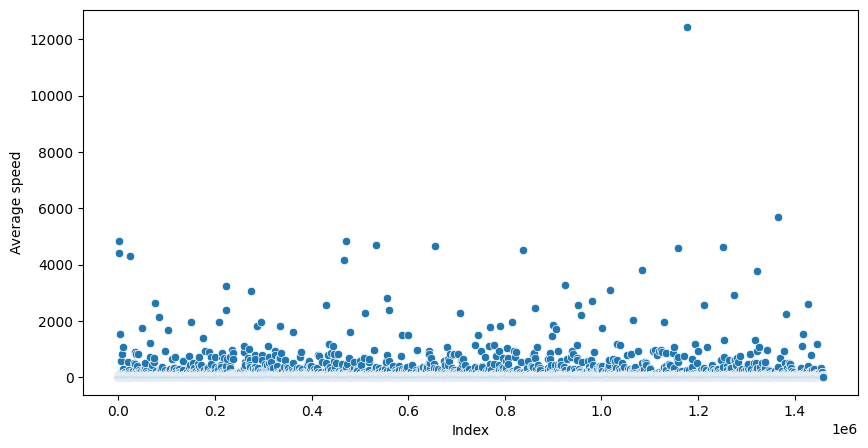

In [157]:
avg_speed = df['total_distance'] / df['trip_duration'] * 3.6
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x=avg_speed.index, y=avg_speed, ax=ax)
ax.set_xlabel('Index')
ax.set_ylabel('Average speed');

In [158]:
# выводим результат
print(f'Минимальная средняя скорость движения: {avg_speed.min():.2f} км/ч')
print(f'Максимальная средняя скорость движения: {avg_speed.max():.2f} км/ч')

Минимальная средняя скорость движения: 0.00 км/ч
Максимальная средняя скорость движения: 12428.38 км/ч


Как раз отсюда мы видим, что у нас есть “поездки-телепортации”, для которых средняя скорость более 1000 км/ч. Даже есть такая, средняя скорость которой составляла более 12000 км/ч! 

Давайте условимся, что предельная средняя скорость, которую могут развивать таксисты будет 300 км/ч. 


### Задание 2.11.
Найдите поездки, длительность которых превышает 24 часа. И удалите их из набора данных.

а) Сколько выбросов по признаку длительности поездки вам удалось найти?

Найдите поездки, средняя скорость которых по кратчайшему пути превышает 300 км/ч и удалите их из данных. 

б) Сколько выбросов по признаку скорости вам удалось найти?

In [159]:
# задаём маску по длительности поезки - выше более 86400 сек (1 сутки)
mask_day_duration = df['trip_duration'] > 86400

# ответ на вопрос а)
print(f'Число выбросов по признаку "длительность поездки": {df[mask_day_duration].shape[0]}')

# удаляем выбросы
df = df[~mask_day_duration]

Число выбросов по признаку "длительность поездки": 4


In [160]:
# добавляем новый признак avg_speed в основной датафрейм
df['avg_speed'] = avg_speed

# задаём маску по средней скорости - выше 300
mask_speed = df['avg_speed'] > 300

# ответ на вопрос б)
print(f'Число выбросов по признаку "средняя скорость поездки": {df[mask_speed].shape[0]}')

# удаляем выбросы
df = df[~mask_speed]

# из основного датафрейма убираем ненужные признаки
df.drop(columns=['avg_speed'], inplace=True)

Число выбросов по признаку "средняя скорость поездки": 407


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458233 entries, 0 to 1458643
Data columns (total 26 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458233 non-null  object        
 1   vendor_id           1458233 non-null  int64         
 2   pickup_datetime     1458233 non-null  datetime64[ns]
 3   dropoff_datetime    1458233 non-null  object        
 4   passenger_count     1458233 non-null  int64         
 5   pickup_longitude    1458233 non-null  float64       
 6   pickup_latitude     1458233 non-null  float64       
 7   dropoff_longitude   1458233 non-null  float64       
 8   dropoff_latitude    1458233 non-null  float64       
 9   store_and_fwd_flag  1458233 non-null  object        
 10  trip_duration       1458233 non-null  int32         
 11  pickup_date         1458233 non-null  datetime64[ns]
 12  pickup_hour         1458233 non-null  int8          
 13  pickup_day_of_wee

## 3. Разведывательный анализ данных (EDA)

В этой части нашего проекта мы с вами:
* Исследуем сформированный набор данных; 
* Попробуем найти закономерности, позволяющие сформулировать предварительные гипотезы относительно того, какие факторы являются решающими в определении длительности поездки;
* Дополним наш анализ визуализациями, иллюстрирующими; исследование. Постарайтесь оформлять диаграммы с душой, а не «для галочки»: навыки визуализации полученных выводов обязательно пригодятся вам в будущем.


Начинаем с целевого признака. Забегая вперед, скажем, что основной метрикой качества решения поставленной задачи будет RMSLE - Root Mean Squared Log Error, которая вычисляется на основе целевой переменной в логарифмическом масштабе. В таком случае целесообразно сразу логарифмировать признак длительности поездки и рассматривать при анализе логарифм в качестве целевого признака:
$$trip\_duration\_log = log(trip\_duration+1),$$
где под символом log подразумевается натуральный логарифм.


In [162]:
df['trip_duration_log'] = np.log(df['trip_duration']+1)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458233 entries, 0 to 1458643
Data columns (total 27 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458233 non-null  object        
 1   vendor_id           1458233 non-null  int64         
 2   pickup_datetime     1458233 non-null  datetime64[ns]
 3   dropoff_datetime    1458233 non-null  object        
 4   passenger_count     1458233 non-null  int64         
 5   pickup_longitude    1458233 non-null  float64       
 6   pickup_latitude     1458233 non-null  float64       
 7   dropoff_longitude   1458233 non-null  float64       
 8   dropoff_latitude    1458233 non-null  float64       
 9   store_and_fwd_flag  1458233 non-null  object        
 10  trip_duration       1458233 non-null  int32         
 11  pickup_date         1458233 non-null  datetime64[ns]
 12  pickup_hour         1458233 non-null  int8          
 13  pickup_day_of_wee

### Задание 3.1.
Постройте гистограмму и коробчатую диаграмму длительности поездок в логарифмическом масштабе (trip_duration_log). 
Исходя из визуализации, сделайте предположение, является ли полученное распределение нормальным? 
Проверьте свою гипотезу с помощью теста Д’Агостино при уровне значимости $\alpha=0.05$. 

а) Чему равен вычисленный p-value? Ответ округлите до сотых.

б) Является ли распределение длительности поездок в логарифмическом масштабе нормальным?

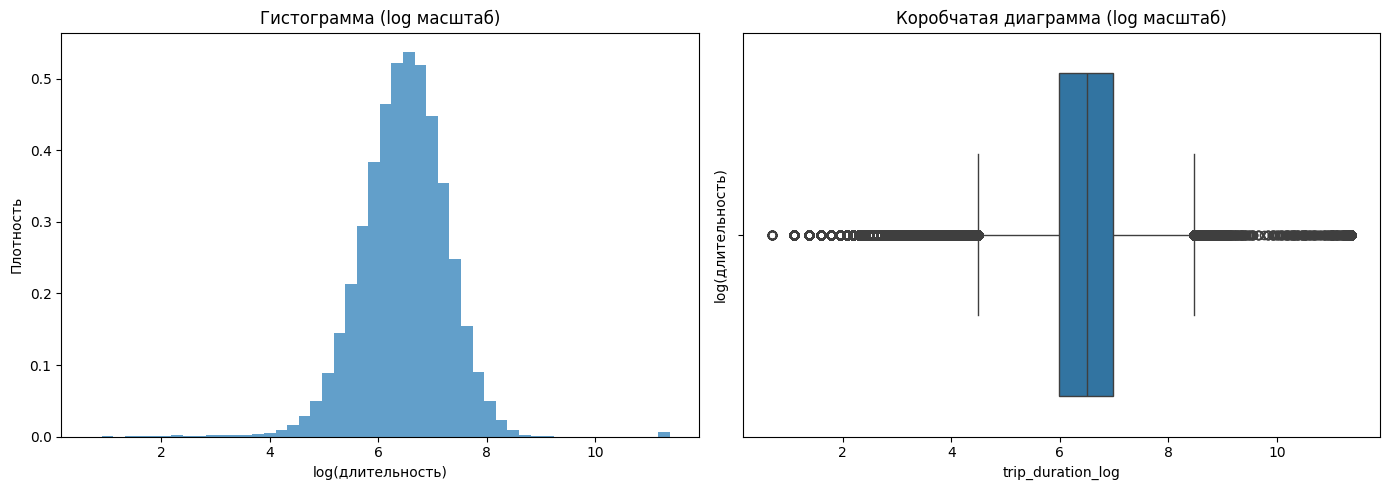

In [163]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
ax1.hist(df['trip_duration_log'].dropna(), bins=50, density=True, alpha=0.7)
ax1.set_title('Гистограмма (log масштаб)')
ax1.set_xlabel('log(длительность)')
ax1.set_ylabel('Плотность')

# Коробчатая диаграмма
sns.boxplot(x=df['trip_duration_log'], ax=ax2)
ax2.set_title('Коробчатая диаграмма (log масштаб)')
ax2.set_ylabel('log(длительность)')

plt.tight_layout()
plt.show()

In [164]:
# Нулевая гипотеза
H_0 = 'Данные имеют нормальное (гауссово) распределение'

# Альтернативная гипотеза
H_a = 'Распределение данных отлично от нормального'

# Уровень значимости
alpha = 0.05

# Тест Д'Агостино
stat, p_value = stats.normaltest(df['trip_duration_log'])
p_value_rounded = round(p_value, 4)

# Результат
if p_value > alpha:
    print(f"✅ Не отвергаем нулевую гипотезу.")
    print(f"   {H_0}")
    print(f"   (P-value = {p_value_rounded} > {alpha})")
else:
    print(f"❌ Отвергаем нулевую гипотезу.")
    print(f"   {H_a}")
    print(f"   (P-value = {p_value_rounded} < {alpha})")

❌ Отвергаем нулевую гипотезу.
   Распределение данных отлично от нормального
   (P-value = 0.0 < 0.05)


In [165]:
# ответ на вопрос а)
print(f'Вычисленный p-value: {p_value}')

Вычисленный p-value: 0.0


### Задание 3.2.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от таксопарка (vendor_id). 

Сравните два распределения между собой.

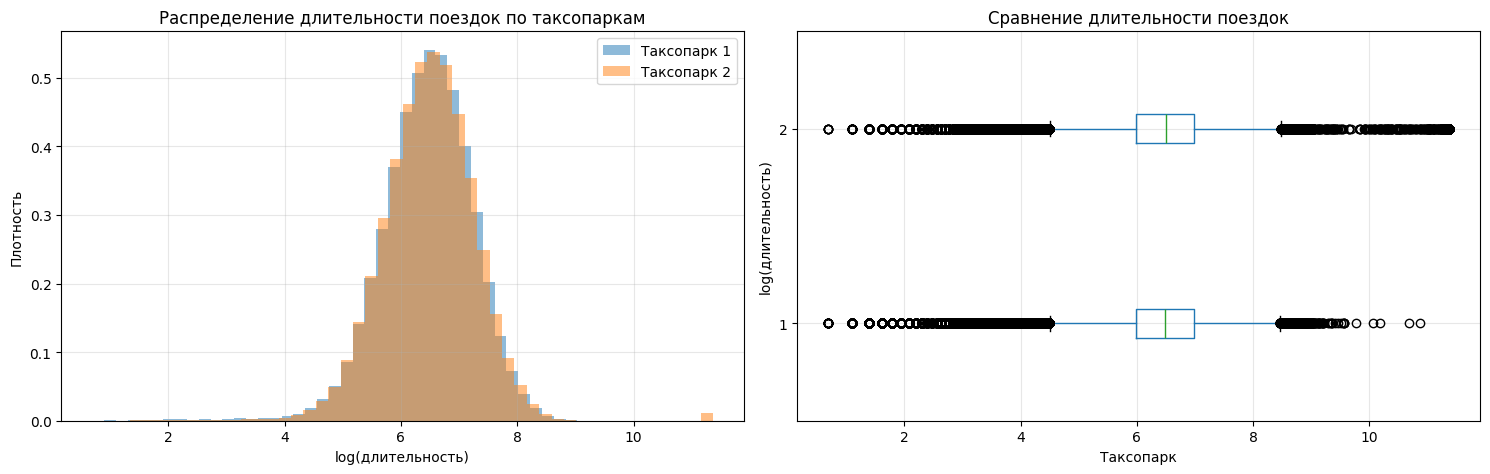

              count      mean       std       min       25%      50%  \
vendor_id                                                              
1          678115.0  6.451452  0.783984  0.693147  5.981414  6.49224   
2          780118.0  6.482619  0.799493  0.693147  5.991465  6.50279   

                75%        max  
vendor_id                       
1          6.974479  10.866223  
2          6.988413  11.366662  


In [166]:
# Создание фигуры
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Гистограмма (совмещенная)
for vendor in [1, 2]:
    data = df[df['vendor_id'] == vendor]['trip_duration_log'].dropna()
    axes[0].hist(data, bins=50, alpha=0.5, label=f'Таксопарк {vendor}', density=True)
axes[0].set_title('Распределение длительности поездок по таксопаркам')
axes[0].set_xlabel('log(длительность)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Коробчатая диаграмма
df.boxplot(column='trip_duration_log', by='vendor_id', ax=axes[1], vert=False)
axes[1].set_title('Сравнение длительности поездок')
axes[1].set_xlabel('Таксопарк')
axes[1].set_ylabel('log(длительность)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('')  # Убираем автоматический заголовок
plt.tight_layout()
plt.show()

# Статистика
print(df.groupby('vendor_id')['trip_duration_log'].describe())

*Вывод:* Распределения в группах практически не отличаются, признак vendor_id не имеет значения при определении длительности поездки.

### Задание 3.3.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от признака отправки сообщения поставщику (store_and_fwd_flag). 

Сравните два распределения между собой.

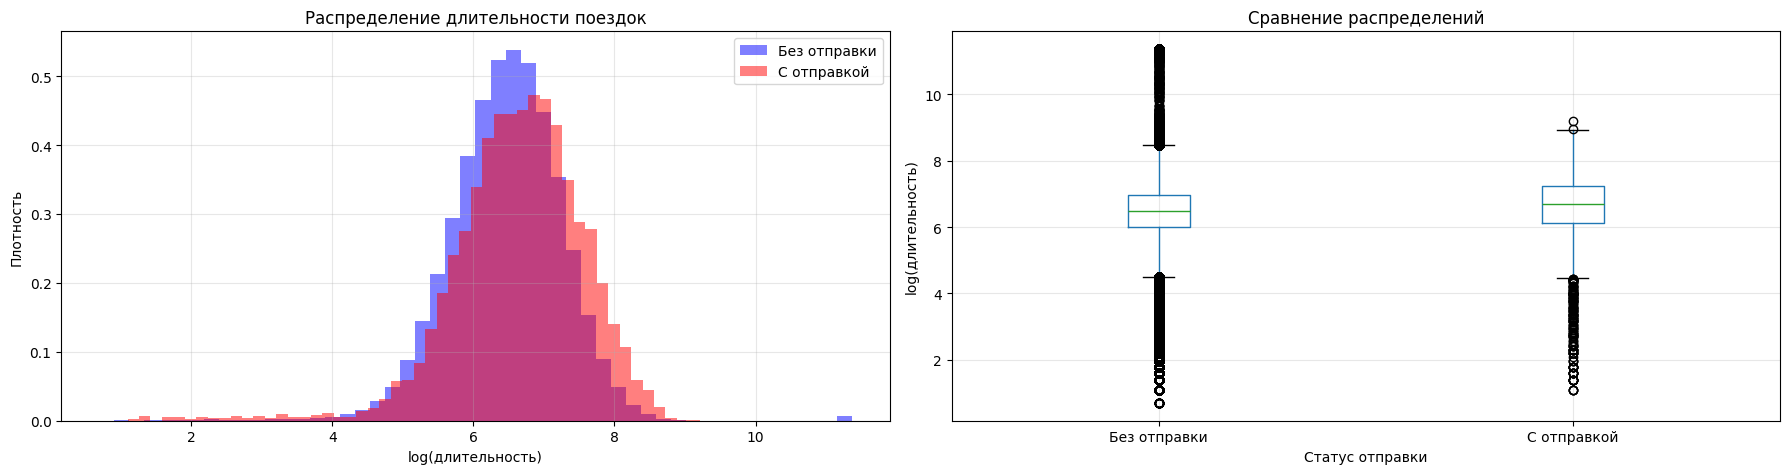


Статистика по группам:
                  count     mean       std       min       25%       50%  \
flag_label                                                                 
Без отправки  1450192.0  6.46721  0.791476  0.693147  5.986452  6.496775   
С отправкой      8041.0  6.63329  0.940689  1.098612  6.124683  6.701960   

                   75%        max  
flag_label                         
Без отправки  6.980076  11.366662  
С отправкой   7.245655   9.208839  


In [167]:
# Подготовка данных
df['trip_duration_log'] = np.log1p(df['trip_duration'])
df['flag_label'] = df['store_and_fwd_flag'].map({'N': 'Без отправки', 'Y': 'С отправкой'})

# Создание фигуры
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Совмещенная гистограмма
for flag, color in zip(['Без отправки', 'С отправкой'], ['blue', 'red']):
    data = df[df['flag_label'] == flag]['trip_duration_log'].dropna()
    axes[0].hist(data, bins=50, alpha=0.5, color=color, label=flag, density=True)
axes[0].set_title('Распределение длительности поездок')
axes[0].set_xlabel('log(длительность)')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Коробчатая диаграмма
df.boxplot(column='trip_duration_log', by='flag_label', ax=axes[1])
axes[1].set_title('Сравнение распределений')
axes[1].set_xlabel('Статус отправки')
axes[1].set_ylabel('log(длительность)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика по группам:")
print(df.groupby('flag_label')['trip_duration_log'].describe())

del df['flag_label']

*Вывод:* Распределения в группах отличаются, признак store_and_fwd_flag имеет значение при определении длительности поездки.

### Задание 3.4.
Постройте две визуализации:
* Распределение количества поездок в зависимости от часа дня;
* Зависимость медианной длительности поездки от часа дня.

На основе построенных графиков ответьте на следующие вопросы:

а) В какое время суток такси заказывают реже всего?

б) В какое время суток наблюдается пик медианной длительности поездок?

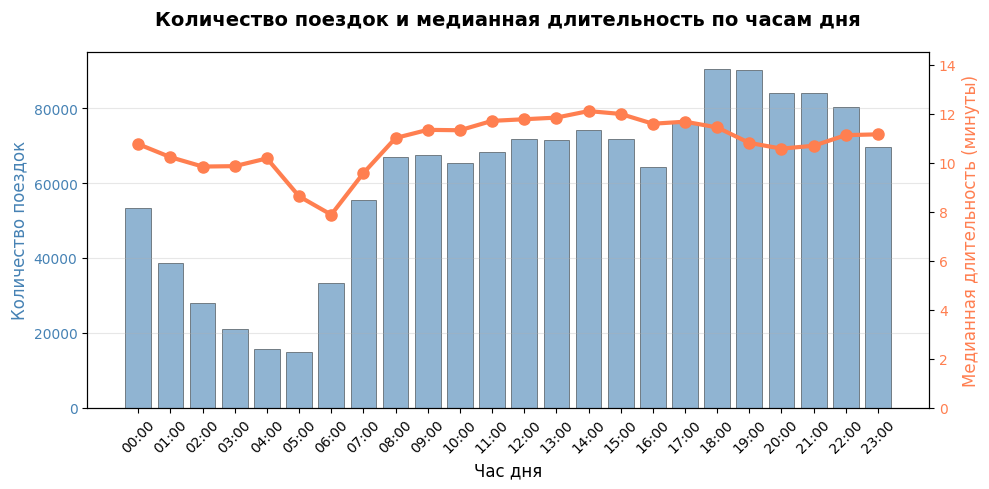

In [168]:
# Агрегация данных по часам
hourly_stats = df.groupby('pickup_hour').agg(
    count=('trip_duration', 'size'),
    median_duration=('trip_duration', 'median')
).reset_index()

# Преобразуем длительность в минуты
hourly_stats['median_duration_min'] = hourly_stats['median_duration'] / 60

# Строим график
fig, ax1 = plt.subplots(figsize=(10, 5))

# Столбчатая диаграмма для количества поездок (левая ось)
color1 = 'steelblue'
bars = ax1.bar(hourly_stats['pickup_hour'], hourly_stats['count'], 
               color=color1, alpha=0.6, edgecolor='black', linewidth=0.5, width=0.8)
ax1.set_xlabel('Час дня', fontsize=12)
ax1.set_ylabel('Количество поездок', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, 24))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24)], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Линейный график для медианной длительности (правая ось)
color2 = 'coral'
ax2 = ax1.twinx()
ax2.plot(hourly_stats['pickup_hour'], hourly_stats['median_duration_min'], 
         color=color2, marker='o', linewidth=3, markersize=8, label='Медианная длительность')
ax2.set_ylabel('Медианная длительность (минуты)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, hourly_stats['median_duration_min'].max() * 1.2)

# Добавление заголовка
plt.title('Количество поездок и медианная длительность по часам дня', 
          fontsize=14, fontweight='bold', pad=20)

fig.tight_layout()
plt.show()

*Выводы:* 
- Реже всего такси заказывают в промежуток с 00:00 по 5:00
- Пик медианной длительности поездок наблюдается с 13:00 по 18:00

### Задание 3.5.
Постройте две визуализации:
* Распределение количества поездок в зависимости от дня недели;
*  Зависимость медианной длительности поездки от дня недели.

На основе построенных графиков ответьте на следующие вопросы:
а) В какой день недели совершается больше всего поездок?
б) В какой день недели медианная длительность поездок наименьшая?


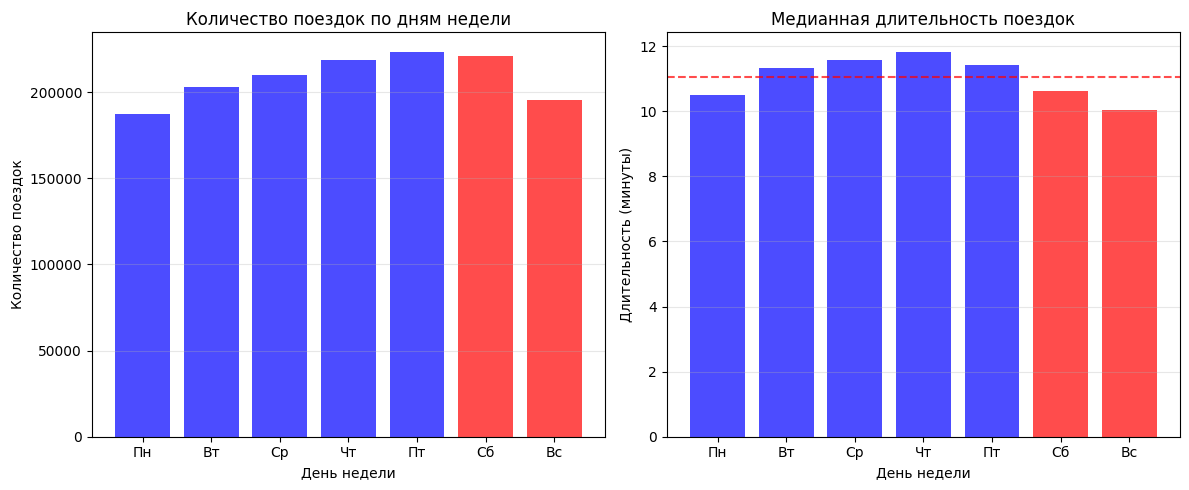

In [169]:
# Подготовка данных
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['trip_duration_min'] = df['trip_duration'] / 60

# Названия дней
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
day_names_full = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

# Агрегация
weekly = df.groupby('pickup_day_of_week').agg(
    count=('trip_duration', 'size'),
    median=('trip_duration_min', 'median')
).reindex(range(7))

# График 1: Количество поездок
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['blue']*5 + ['red']*2
plt.bar(days, weekly['count'], color=colors, alpha=0.7)
plt.title('Количество поездок по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3, axis='y')

# График 2: Медианная длительность
plt.subplot(1, 2, 2)
plt.bar(days, weekly['median'], color=colors, alpha=0.7)
plt.title('Медианная длительность поездок')
plt.xlabel('День недели')
plt.ylabel('Длительность (минуты)')
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=df['trip_duration_min'].median(), color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

del df['trip_duration_min']

*Выводы:*
- Больше всего поездок совершается в пятницу
- Медианная длительность поездок наименьшая в воскресенье

### Задание 3.6.
Посмотрим на обе временные характеристики одновременно. 

Постройте сводную таблицу, по строкам которой отложены часы (pickup_hour), по столбцам - дни недели (pickup_day_of_week), а в ячейках - медианная длительность поездки (trip_duration). 

Визуализируйте полученную сводную таблицу с помощью тепловой карты (рекомендуемая палитра - coolwarm).

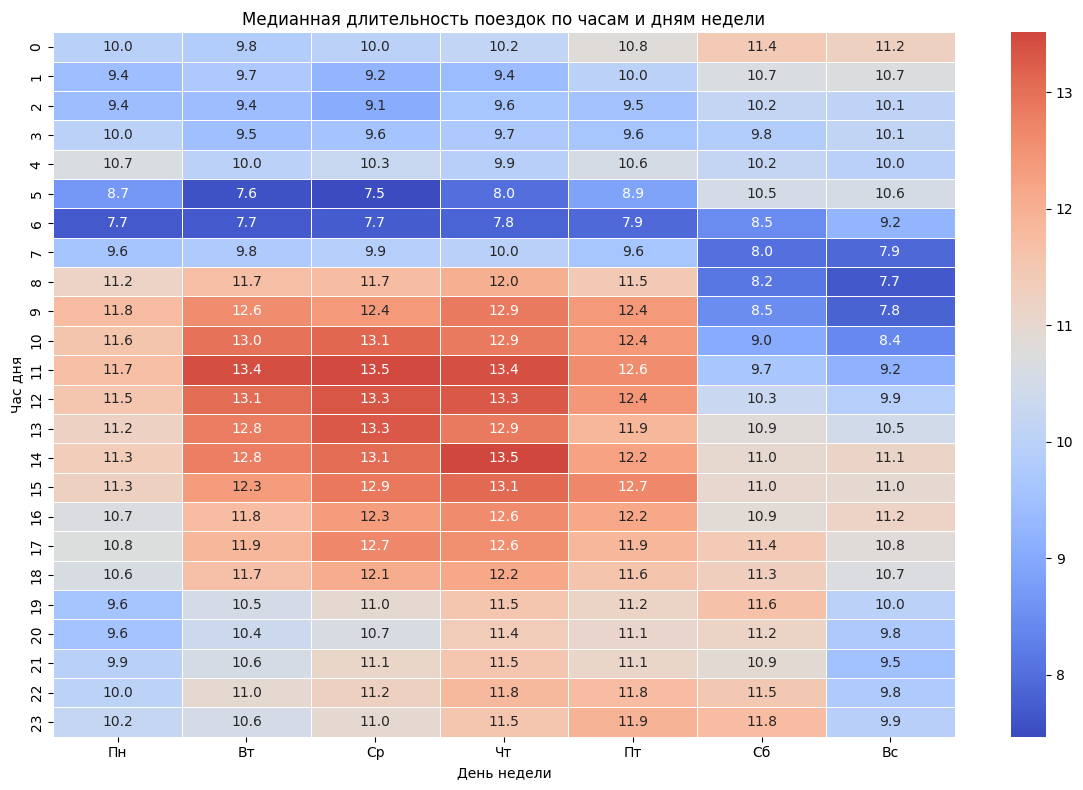

In [170]:
# Создание сводной таблицы
pivot = pd.pivot_table(
    df,
    values='trip_duration',
    index='pickup_hour',
    columns='pickup_day_of_week',
    aggfunc='median'
) / 60  # переводим в минуты

# Переименование столбцов
pivot.columns = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# Тепловая карта
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm', 
            center=pivot.mean().mean(), linewidths=0.5)
plt.title('Медианная длительность поездок по часам и дням недели')
plt.xlabel('День недели')
plt.ylabel('Час дня')
plt.tight_layout()
plt.show()

*Выводы:*
- Самые продолжительные поездки (в медианном смысле) наблюдаются с понедельника по пятницу в промежутке с 8 до 18 часов.
- Наибольшая медианная длительность поездки наблюдалась в четверг в 14 часов дня.

### Задание 3.7.
Постройте две диаграммы рассеяния (scatter-диаграммы):
* первая должна иллюстрировать географическое расположение точек начала поездок (pickup_longitude, pickup_latitude) 
* вторая должна географическое расположение точек завершения поездок (dropoff_longitude, dropoff_latitude).

Для этого на диаграммах по оси абсцисс отложите широту (longitude), а по оси ординат - долготу (latitude). 
Включите в визуализацию только те точки, которые находятся в пределах Нью-Йорка - добавьте следующие ограничения на границы осей абсцисс и ординат:
 
city_long_border = (-74.03, -73.75)

city_lat_border = (40.63, 40.85)

Добавьте на диаграммы расцветку по десяти географическим кластерам (geo_cluster), которые мы сгенерировали ранее. 

**Рекомендация:** для наглядности уменьшите размер точек на диаграмме рассеяния.  


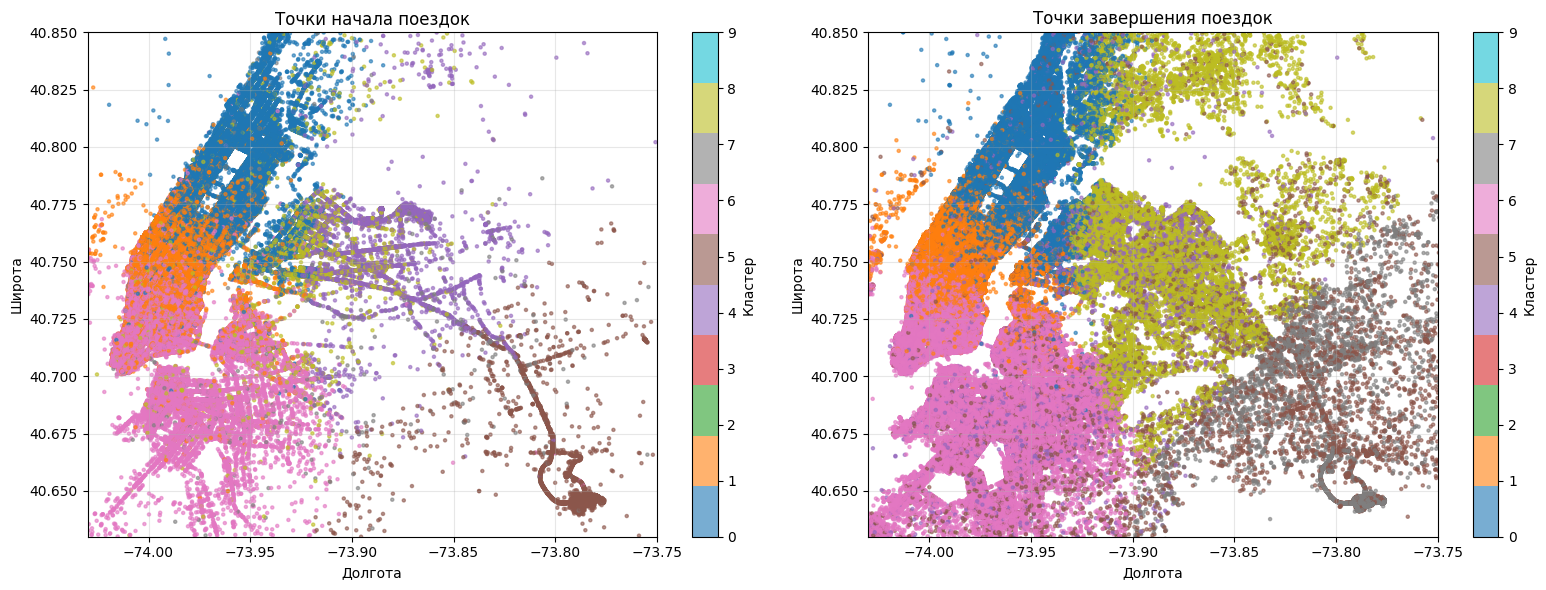

In [171]:
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)

# Фильтрация данных
df_ny = df[
    df['pickup_longitude'].between(*city_long_border) &
    df['pickup_latitude'].between(*city_lat_border)
].copy()

# Создание фигуры
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Начальные точки
scatter1 = ax1.scatter(
    df_ny['pickup_longitude'],
    df_ny['pickup_latitude'],
    c=df_ny['geo_cluster'],
    cmap='tab10',
    s=5,
    alpha=0.6
)
ax1.set_title('Точки начала поездок')
ax1.set_xlabel('Долгота')
ax1.set_ylabel('Широта')
ax1.set_xlim(city_long_border)
ax1.set_ylim(city_lat_border)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Кластер')

# График 2: Конечные точки
scatter2 = ax2.scatter(
    df_ny['dropoff_longitude'],
    df_ny['dropoff_latitude'],
    c=df_ny['geo_cluster'],
    cmap='tab10',
    s=5,
    alpha=0.6
)
ax2.set_title('Точки завершения поездок')
ax2.set_xlabel('Долгота')
ax2.set_ylabel('Широта')
ax2.set_xlim(city_long_border)
ax2.set_ylim(city_lat_border)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Кластер')

plt.tight_layout()
plt.show()

In [172]:
# Границы Нью-Йорка
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)

# Находим все уникальные кластеры
all_clusters = set(df['geo_cluster'].unique())

# Находим кластеры, у которых есть точки в пределах Нью-Йорка
clusters_in_ny = set()

for _, row in df.iterrows():
    # Проверяем начальную точку
    if (city_long_border[0] <= row['pickup_longitude'] <= city_long_border[1] and
        city_lat_border[0] <= row['pickup_latitude'] <= city_lat_border[1]):
        clusters_in_ny.add(row['geo_cluster'])
    
    # Проверяем конечную точку
    if (city_long_border[0] <= row['dropoff_longitude'] <= city_long_border[1] and
        city_lat_border[0] <= row['dropoff_latitude'] <= city_lat_border[1]):
        clusters_in_ny.add(row['geo_cluster'])

# Кластеры за пределами
clusters_outside = all_clusters - clusters_in_ny

print(f"Кластеров за пределами Нью-Йорка: {len(clusters_outside)}")
print(f"Кластеров внутри Нью-Йорка: {len(clusters_in_ny)}")

Кластеров за пределами Нью-Йорка: 2
Кластеров внутри Нью-Йорка: 8


## 4. Отбор и преобразование признаков

Перед тем как перейти к построению модели, осталось сделать ещё несколько шагов.
* Следует помнить, что многие алгоритмы машинного обучения не могут обрабатывать категориальные признаки в их обычном виде. Поэтому нам необходимо их закодировать;
* Надо отобрать признаки, которые мы будем использовать для обучения модели;
*  Необходимо масштабировать и трансформировать некоторые признаки для того, чтобы улучшить сходимость моделей, в основе которых лежат численные методы.


In [173]:
print('Shape of data: {}'.format(df.shape))
print('Columns: {}'.format(df.columns))

Shape of data: (1458233, 27)
Columns: Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind speed', 'precip', 'events',
       'trip_duration_log'],
      dtype='object')


Для удобства работы сделаем копию исходной таблицы с поездками:

In [174]:
train_data = df.copy()
train_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,number_of_steps,haversine_distance,direction,geo_cluster,temperature,visibility,wind speed,precip,events,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,5,1.498521,99.970196,0,4.4,8.0,27.8,0.3,None,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,6,1.805507,-117.153768,6,28.9,16.1,7.4,0.0,None,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,16,6.385098,-159.680165,6,-6.7,16.1,24.1,0.0,None,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,4,1.485498,-172.737700,6,7.2,16.1,25.9,0.0,None,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,5,1.188588,179.473585,0,9.4,16.1,9.3,0.0,None,6.077642


### Задание 4.1.
Сразу позаботимся об очевидных неинформативных и избыточных признаках. 

а) Какой из признаков является уникальным для каждой поездки и не несет полезной информации в определении ее продолжительности?

б) Утечка данных (data leak) - это…

в) Подумайте, наличие какого из признаков в обучающем наборе данных создает утечку данных?

г) Исключите выбранные в пунктах а) и в) признаки из исходной таблицы с данными. Сколько столбцов в таблице у вас осталось?


- *Ответ а*: Уникальным для каждой поездки является её идентификатор — столбец id. Он никак не связан с длительностью поездки и не имеет значения при её прогнозировании.
- *Ответ б*: Утечка данных (data leak) — это ситуация, в которой данные используемые для обучения модели, содержат прямую или косвенную информацию о целевой переменной, но эти данные недоступны в реальных условиях.
- *Ответ в*: В наших данных утечку создаёт признак dropoff_datetime — зафиксированное время остановки счётчика. Начиная поездку, мы никак не можем точно знать, когда она закончится, ведь мы как раз и пытаемся предсказать время окончания поездки.

In [175]:
train_data.drop(columns=['id', 'dropoff_datetime'], axis=1, inplace=True)

# ответ на вопрос г)
print(f'Размер датафрейма: {train_data.shape}')

Размер датафрейма: (1458233, 25)


Ранее мы извлекли всю необходимую для нас информацию из даты начала поездки, теперь мы можем избавиться от этих признаков, так как они нам больше не понадобятся:


In [176]:
drop_columns = ['pickup_datetime', 'pickup_date']
train_data = train_data.drop(drop_columns, axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 23)


### Задание 4.2.

Закодируйте признак vendor_id в таблице train_data таким образом, чтобы он был равен 0, если идентификатор таксопарка равен 1, и 1 — в противном случае.

Закодируйте признак store_and_fwd_flag в таблице train_data таким образом, чтобы он был равен 0, если флаг выставлен в значение 'N', и 1 — в противном случае.

а) Рассчитайте среднее по закодированному столбцу vendor_id. Ответ приведите с точностью до сотых.

б) Рассчитайте среднее по закодированному столбцу store_and_fwd_flag. Ответ приведите с точностью до тысячных.



In [177]:
# Кодирование признаков
train_data['vendor_id'] = (train_data['vendor_id'] != 1).astype(int)
train_data['store_and_fwd_flag'] = (train_data['store_and_fwd_flag'] != 'N').astype(int)

# Расчет средних
vendor_mean = train_data['vendor_id'].mean()
flag_mean = train_data['store_and_fwd_flag'].mean()

# Вывод результатов с нужной точностью
print(f"а) Среднее vendor_id: {vendor_mean:.2f}")
print(f"б) Среднее store_and_fwd_flag: {flag_mean:.3f}")

а) Среднее vendor_id: 0.53
б) Среднее store_and_fwd_flag: 0.006


### Задание 4.3.
Создайте таблицу data_onehot из закодированных однократным кодированием признаков pickup_day_of_week, geo_cluster и events в таблице train_data с помощью OneHotEncoder из библиотеки sklearn. Параметр drop выставите в значение 'first', чтобы удалять первый бинарный столбец, тем самым не создавая излишних признаков.

В параметре handle_unknown установите значение 'ignore'. Это позволит коду отработать без ошибок в случае появления в тестовой выборке значений, отсутствующих в обучающей выборке.

В результате работы OneHotEncoder вы получите безымянный numpy-массив, который нам будет необходимо преобразовать обратно в DataFrame, для более удобной работы в дальнейшем. Чтобы получить имена закодированных столбцов у объекта типа OneHotEncoder есть специальный метод get_feature_names_out(). Он возвращает список новых закодированных имен столбцов в формате <оригинальное имя столбца>_<имя категории>.

Пример использования:

``` python
# Объявляем кодировщик
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
# Получаем закодированные имена столбцов
column_names = one_hot_encoder.get_feature_names_out()
# Составляем DataFrame из закодированных признаков
data_onehot = pd.DataFrame(data_onehot, columns=column_names)
```

В этом псевдокоде:
* one_hot_encoder - объект класса OneHotEncoder
* data_onehot - numpy-массив, полученный в результате трансформации кодировщиком

В результате выполнения задания у вас должен быть образован DataFrame `data_onehot`, который содержит кодированные категориальные признаки pickup_day_of_week, geo_cluster и events. 


Сколько бинарных столбцов у вас получилось сгенерировать с помощью однократного кодирования?


In [178]:
from sklearn.preprocessing import OneHotEncoder

# список признаков для кодирования
columns_to_change = ['pickup_day_of_week', 'geo_cluster', 'events']

# создаём объект класса OneHotEncoder
OHE_encoder = preprocessing.OneHotEncoder(drop='first')

# выполняем OneHot-кодирование
data_onehot = OHE_encoder.fit_transform(train_data[columns_to_change]).toarray()
ohe_column_names = OHE_encoder.get_feature_names_out(columns_to_change)

# составляем датафрейм из OneHot-закодированных признаков
data_onehot = pd.DataFrame(data_onehot, columns=ohe_column_names)

# понижаем размерность признаков по типу занимаемых данных
data_onehot = data_onehot.astype('int8')

# выводим результат
print(data_onehot.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458233 entries, 0 to 1458232
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   pickup_day_of_week_1  1458233 non-null  int8 
 1   pickup_day_of_week_2  1458233 non-null  int8 
 2   pickup_day_of_week_3  1458233 non-null  int8 
 3   pickup_day_of_week_4  1458233 non-null  int8 
 4   pickup_day_of_week_5  1458233 non-null  int8 
 5   pickup_day_of_week_6  1458233 non-null  int8 
 6   geo_cluster_1         1458233 non-null  int8 
 7   geo_cluster_2         1458233 non-null  int8 
 8   geo_cluster_3         1458233 non-null  int8 
 9   geo_cluster_4         1458233 non-null  int8 
 10  geo_cluster_5         1458233 non-null  int8 
 11  geo_cluster_6         1458233 non-null  int8 
 12  geo_cluster_7         1458233 non-null  int8 
 13  geo_cluster_8         1458233 non-null  int8 
 14  geo_cluster_9         1458233 non-null  int8 
 15  events_None    

Добавим полученную таблицу с закодированными признаками:

In [179]:
train_data = pd.concat(
    [train_data.reset_index(drop=True).drop(columns_to_change, axis=1), data_onehot], 
    axis=1
)
print('Shape of data: {}'.format(train_data.shape))

Shape of data: (1458233, 38)


Теперь, когда категориальные признаки предобработаны, сформируем матрицу наблюдений X, вектор целевой переменной y и его логарифм y_log. В матрицу наблюдений войдут все столбцы из таблицы с поездками за исключением целевого признака trip_duration и его логарифмированной версии trip_duration_log:


In [180]:
X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

Все наши модели мы будем обучать на логарифмированной версии y_log. 

Выбранный тип валидации - hold-out. Разобьем выборку на обучающую и валидационную в соотношении 67/33:

In [181]:
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log, 
    test_size=0.33, 
    random_state=42
)

На данный момент у нас достаточно много признаков: скорее всего, не все из них будут важны. Давайте оставим лишь те, которые сильнее всего связаны с целевой переменной и точно будут вносить вклад в повышение качества модели.


### Задание 4.4.
С помощью SelectKBest отберите 25 признаков, наилучшим образом подходящих для предсказания целевой переменной в логарифмическом масштабе. Отбор реализуйте по обучающей выборке, используя параметр score_func = f_regression.

Укажите признаки, которые вошли в список отобранных


In [182]:
# выбираем лучшие признаки по методу "выбор k лучших переменных" (SelectKBest)
SKB_selector = feature_selection.SelectKBest(feature_selection.f_regression, k=25)
SKB_selector.fit(X_train, y_train_log)

# выводим отобранные признаки
SKB_selector_cols = list(SKB_selector.get_feature_names_out())
SKB_selector_cols

['vendor_id',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag',
 'pickup_hour',
 'pickup_holiday',
 'total_distance',
 'total_travel_time',
 'number_of_steps',
 'haversine_distance',
 'temperature',
 'pickup_day_of_week_1',
 'pickup_day_of_week_2',
 'pickup_day_of_week_3',
 'pickup_day_of_week_4',
 'pickup_day_of_week_5',
 'pickup_day_of_week_6',
 'geo_cluster_1',
 'geo_cluster_4',
 'geo_cluster_5',
 'geo_cluster_7',
 'geo_cluster_8']

In [183]:
# выбираем k-признаки из данных
X_train = X_train[SKB_selector_cols]
X_valid = X_valid[SKB_selector_cols]

# выводим результат
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 977016 entries, 293850 to 121958
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vendor_id             977016 non-null  int32  
 1   passenger_count       977016 non-null  int64  
 2   pickup_longitude      977016 non-null  float64
 3   pickup_latitude       977016 non-null  float64
 4   dropoff_longitude     977016 non-null  float64
 5   dropoff_latitude      977016 non-null  float64
 6   store_and_fwd_flag    977016 non-null  int32  
 7   pickup_hour           977016 non-null  int8   
 8   pickup_holiday        977016 non-null  int8   
 9   total_distance        977016 non-null  float64
 10  total_travel_time     977016 non-null  float64
 11  number_of_steps       977016 non-null  int8   
 12  haversine_distance    977016 non-null  float64
 13  temperature           977016 non-null  float64
 14  pickup_day_of_week_1  977016 non-null  int8   
 15  

In [184]:
print(X_valid.info())

<class 'pandas.core.frame.DataFrame'>
Index: 481217 entries, 452652 to 1108352
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vendor_id             481217 non-null  int32  
 1   passenger_count       481217 non-null  int64  
 2   pickup_longitude      481217 non-null  float64
 3   pickup_latitude       481217 non-null  float64
 4   dropoff_longitude     481217 non-null  float64
 5   dropoff_latitude      481217 non-null  float64
 6   store_and_fwd_flag    481217 non-null  int32  
 7   pickup_hour           481217 non-null  int8   
 8   pickup_holiday        481217 non-null  int8   
 9   total_distance        481217 non-null  float64
 10  total_travel_time     481217 non-null  float64
 11  number_of_steps       481217 non-null  int8   
 12  haversine_distance    481217 non-null  float64
 13  temperature           481217 non-null  float64
 14  pickup_day_of_week_1  481217 non-null  int8   
 15 

Так как мы будем использовать различные модели, в том числе внутри которых заложены численные методы оптимизации, то давайте заранее позаботимся о масштабировании факторов. 


### Задание 4.5.
Нормализуйте предикторы в обучающей и валидационной выборках с помощью MinMaxScaler из библиотеки sklearn. Помните, что обучение нормализатора производится на обучающей выборке, а трансформация на обучающей и валидационной!

Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из валидационной выборки. Ответ округлите до сотых.


In [185]:
# задаём объект класса скейлер MinMaxScaler
MMS_scaler = preprocessing.MinMaxScaler()

# обучаем скейлер, подгоняем данные
MMS_scaler.fit(X_train)

# транформируем данные обученным скейлером
X_train_scaled = MMS_scaler.transform(X_train)
X_valid_scaled = MMS_scaler.transform(X_valid)

In [186]:
# ответ на вопрос
print(f'Среднее арифметическое первого предиктора: {X_valid_scaled[:, 0].mean():.2f}')

Среднее арифметическое первого предиктора: 0.54


## 5. Решение задачи регрессии: линейная регрессия и деревья решений

Определим метрику, по которой мы будем измерять качество наших моделей. Мы будем следовать канонам исходного соревнования на Kaggle и в качестве метрики использовать RMSLE (Root Mean Squared Log Error), которая вычисляется как:
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2},$$
где:
* $y_i$ - истинная длительность i-ой поездки на такси (trip_duration)
* $\hat{y_i}$- предсказанная моделью длительность i-ой поездки на такси

Заметим, что логарифмирование целевого признака мы уже провели заранее, поэтому нам будет достаточно вычислить метрику RMSE для модели, обученной прогнозировать длительность поездки такси в логарифмическом масштабе:
$$z_i=log(y_i+1),$$
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(z_i-\hat{z_i})^2}=\sqrt{MSE(z_i,\hat{z_i})}$$ 



### Задание 5.1.
Постройте модель линейной регрессии на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [187]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_log_error, mean_squared_error

# Обучение модели
model_LR = LinearRegression()
model_LR.fit(X_train_scaled, y_train_log)

# Предсказания
y_train_pred_LR = model_LR.predict(X_train_scaled)
y_valid_pred_LR = model_LR.predict(X_valid_scaled)

# RMSLE
rmsle_train_LR = round(np.sqrt(mean_squared_error(y_train_log, y_train_pred_LR)), 4)
rmsle_valid_LR = round(np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_LR)), 4)

# Вывод
print("="*50)
print("ЛИНЕЙНАЯ РЕГРЕССИЯ")
print("="*50)
print(f"RMSLE на обучающей выборке:     {rmsle_train_LR}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_LR}")
print("="*50)

ЛИНЕЙНАЯ РЕГРЕССИЯ
RMSLE на обучающей выборке:     0.5336
RMSLE на валидационной выборке: 0.5361


### Задание 5.2.
Сгенерируйте полиномиальные признаки 2-ой степени с помощью PolynomialFeatures из библиотеки sklearn. Параметр include_bias выставите в значение False.

Постройте модель полиномиальной регрессии 2-ой степени на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [188]:
# создаём скейлер-генератор полиномиальных признаков
PF_scaler = preprocessing.PolynomialFeatures(include_bias=False)
PF_scaler.fit(X_train_scaled)

# генерируем полиномиальные признаки для тренировочной выборки
X_train_scaled_poly = PF_scaler.transform(X_train_scaled)

# генерируем полиномиальные признаки для тестовой выборки
X_valid_scaled_poly = PF_scaler.transform(X_valid_scaled)

# выводим результат
print(X_train_scaled_poly.shape)
print(X_valid_scaled_poly.shape)

(977016, 350)
(481217, 350)


In [189]:
# Обучение модели
model_poly = LinearRegression()
model_poly.fit(X_train_scaled_poly, y_train_log)

# Предсказания
y_train_pred_poly = model_poly.predict(X_train_scaled_poly)
y_valid_pred_poly = model_poly.predict(X_valid_scaled_poly)

# RMSLE
rmsle_train_poly = round(np.sqrt(mean_squared_error(y_train_log, y_train_pred_poly)), 4)
rmsle_valid_poly = round(np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_poly)), 4)

# Вывод
print("="*50)
print("ЛИНЕЙНАЯ РЕГРЕССИЯ НА ПОЛИНОМИАЛЬНЫХ ПРИЗНАКАХ")
print("="*50)
print(f"RMSLE на обучающей выборке:     {rmsle_train_poly}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_poly}")
print("="*50)

ЛИНЕЙНАЯ РЕГРЕССИЯ НА ПОЛИНОМИАЛЬНЫХ ПРИЗНАКАХ
RMSLE на обучающей выборке:     0.4673
RMSLE на валидационной выборке: 0.6126


### Задание 5.3.
Постройте модель полиномиальной регрессии 2-ой степени с L2-регуляризацией (регуляризация по Тихонову) на обучающей выборке  (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Коэффициент регуляризации $\alpha$ установите равным 1, остальные параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [190]:
from sklearn.linear_model import Ridge

# Обучение модели
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled_poly, y_train_log)

# Предсказания
y_train_pred_ridge = ridge_model.predict(X_train_scaled_poly)
y_valid_pred_ridge = ridge_model.predict(X_valid_scaled_poly)

# RMSLE
rmsle_train_ridge = round(np.sqrt(mean_squared_error(y_train_log, y_train_pred_ridge)), 4)
rmsle_valid_ridge = round(np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_ridge)), 4)

# Вывод
print("="*50)
print("RIDGE")
print("="*50)
print(f"RMSLE на обучающей выборке:     {rmsle_train_ridge}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_ridge}")
print("="*50)

RIDGE
RMSLE на обучающей выборке:     0.4766
RMSLE на валидационной выборке: 0.4801


### Задание 5.4.
Постройте модель дерева решений (DecisionTreeRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию. 

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [191]:
from sklearn.tree import DecisionTreeRegressor

# Обучение модели
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train_log)

# Предсказания
y_train_pred_dt = dt_model.predict(X_train_scaled)
y_valid_pred_dt = dt_model.predict(X_valid_scaled)

# RMSLE
rmsle_train_dt = round(np.sqrt(mean_squared_error(y_train_log, y_train_pred_dt)), 4)
rmsle_valid_dt = round(np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_dt)), 4)

# Вывод
print("="*50)
print("ДЕРЕВО РЕШЕНИЙ")
print("="*50)
print(f"RMSLE на обучающей выборке:     {rmsle_train_dt}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_dt}")
print("="*50)

ДЕРЕВО РЕШЕНИЙ
RMSLE на обучающей выборке:     0.003
RMSLE на валидационной выборке: 0.5642


### Задание 5.5.
Переберите все возможные варианты глубины дерева решений в диапазоне от 7 до 20:

max_depths = range(7, 20)

Параметр random_state задайте равным 42.

Постройте линейные графики изменения метрики RMSE на тренировочной и валидационной выборках в зависимости от значения параметра глубины дерева решений. 

а) Найдите оптимальное значение максимальной глубины дерева, для которой будет наблюдаться минимальное значение RMSLE на обучающей выборке, но при этом еще не будет наблюдаться переобучение (валидационная кривая еще не начинает возрастать).

б) Чему равно значение метрик RMSLE на тренировочной и валидационной выборках для дерева решений с выбранной оптимальной глубиной? Ответ округлите до сотых.


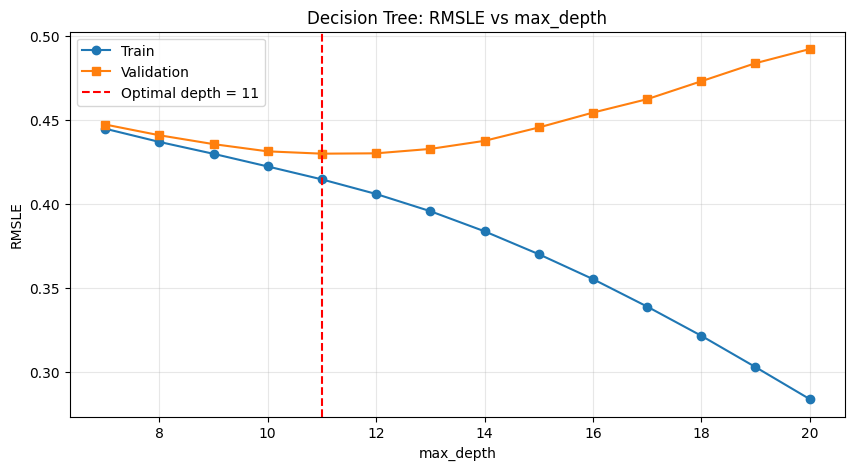

Оптимальная глубина: 11
RMSLE train: 0.4146
RMSLE valid: 0.4299


In [192]:
# Перебор глубины дерева решений
max_depths = range(7, 21)

# Списки для хранения значений RMSLE
train_rmsle = []
valid_rmsle = []

for depth in max_depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train_log)
    
    train_rmsle.append(np.sqrt(mean_squared_error(y_train_log, dt.predict(X_train_scaled))))
    valid_rmsle.append(np.sqrt(mean_squared_error(y_valid_log, dt.predict(X_valid_scaled))))

# Поиск оптимальной глубины (минимум валидационной ошибки)
best_idx = np.argmin(valid_rmsle)
optimal_depth = max_depths[best_idx]
best_train_dt = round(train_rmsle[best_idx], 4)
best_valid_dt = round(valid_rmsle[best_idx], 4)

# График
plt.figure(figsize=(10, 5))
plt.plot(max_depths, train_rmsle, 'o-', label='Train')
plt.plot(max_depths, valid_rmsle, 's-', label='Validation')
plt.axvline(x=optimal_depth, color='r', linestyle='--', label=f'Optimal depth = {optimal_depth}')
plt.xlabel('max_depth')
plt.ylabel('RMSLE')
plt.title('Decision Tree: RMSLE vs max_depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вывод
print(f"Оптимальная глубина: {optimal_depth}")
print(f"RMSLE train: {best_train_dt}")
print(f"RMSLE valid: {best_valid_dt}")

## 6. Решение задачи регрессии: ансамблевые методы и построение прогноза

Переходим к тяжелой артиллерии: ансамблевым алгоритмам. 

### Задание 6.1.

Постройте модель случайного леса на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* n_estimators=200,
* max_depth=12,
* criterion='squared_error',
* min_samples_split=20,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [193]:
from sklearn.ensemble import RandomForestRegressor

# Обучение модели
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    criterion='squared_error',
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train_log)

# Предсказания
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_valid_pred_rf = rf_model.predict(X_valid_scaled)

# RMSLE
rmsle_train_rf = round(np.sqrt(mean_squared_error(y_train_log, y_train_pred_rf)), 4)
rmsle_valid_rf = round(np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_rf)), 4)

# Вывод
print("="*50)
print("СЛУЧАЙНЫЙ ЛЕС")
print("="*50)
print(f"RMSLE на обучающей выборке:     {rmsle_train_rf}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_rf}")
print("="*50)

СЛУЧАЙНЫЙ ЛЕС
RMSLE на обучающей выборке:     0.3991
RMSLE на валидационной выборке: 0.4141


### Задание 6.2.
Постройте модель градиентного бустинга над деревьями решений (GradientBoostingRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* learning_rate=0.5,
* n_estimators=100,
* max_depth=6, 
* min_samples_split=30,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [194]:
from sklearn.ensemble import GradientBoostingRegressor

# Обучение модели
gb_model = GradientBoostingRegressor(
    learning_rate=0.5,
    n_estimators=100,
    max_depth=6,
    min_samples_split=30,
    random_state=42,
    criterion='squared_error'
)
gb_model.fit(X_train_scaled, y_train_log)

# Предсказания
y_train_pred_gb= gb_model.predict(X_train_scaled)
y_valid_pred_gb = gb_model.predict(X_valid_scaled)

# RMSLE
rmsle_train_gb = round(np.sqrt(mean_squared_error(y_train_log, y_train_pred_gb)), 4)
rmsle_valid_gb = round(np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_gb)), 4)

# Вывод
print("="*50)
print("ГРАДИЕНТНЫЙ БУСТИНГ")
print("="*50)
print(f"RMSLE на обучающей выборке:     {rmsle_train_gb}")
print(f"RMSLE на валидационной выборке: {rmsle_valid_gb}")
print("="*50)

ГРАДИЕНТНЫЙ БУСТИНГ
RMSLE на обучающей выборке:     0.3715
RMSLE на валидационной выборке: 0.393


### Задание 6.3.
Какая из построенных вами моделей показала наилучший результат (наименьшее значение RMSLE на валидационной выборке)?
* Линейная регрессия
* Полиномиальная регрессия 2ой степени
* Дерево решений
* Случайный лес
* Градиентный бустинг над деревьями решений


In [195]:
# Собираем результаты всех моделей
results = {
    'Модель': [
        'Linear Regression',
        'Polynomial Linear Regression',
        'Ridge (alpha=1)',
        'Decision Tree (default)',
        'Decision Tree (optimal depth)',
        'Random Forest',
        'Gradient Boosting'
    ],
    'RMSLE Train': [
        rmsle_train_LR,
        rmsle_train_poly,
        rmsle_train_ridge,
        rmsle_train_dt,
        best_train_dt,
        rmsle_train_rf,
        rmsle_train_gb
    ],
    'RMSLE Valid': [
        rmsle_valid_LR,
        rmsle_valid_poly,
        rmsle_valid_ridge,
        rmsle_valid_dt,
        best_valid_dt,
        rmsle_valid_rf,
        rmsle_valid_gb
    ]
}

# Создаём DataFrame
results_df = pd.DataFrame(results)

# Сортируем по валидационной ошибке (от лучшей к худшей)
results_df = results_df.sort_values('RMSLE Valid', ascending=True)


# Вывод
print("="*70)
print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК ВСЕХ МОДЕЛЕЙ")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

ИТОГОВАЯ ТАБЛИЦА МЕТРИК ВСЕХ МОДЕЛЕЙ
                       Модель  RMSLE Train  RMSLE Valid
            Gradient Boosting       0.3715       0.3930
                Random Forest       0.3991       0.4141
Decision Tree (optimal depth)       0.4146       0.4299
              Ridge (alpha=1)       0.4766       0.4801
            Linear Regression       0.5336       0.5361
      Decision Tree (default)       0.0030       0.5642
 Polynomial Linear Regression       0.4673       0.6126


*Вывод*: Градиентный бустинг над деревьями решений показал наилучий результат (наименьшее значение RMSLE на валидационной выборке).

### Задание 6.4.
Постройте столбчатую диаграмму коэффициентов значимости каждого из факторов для наилучшей ансамблевой модели.

Укажите топ-3 наиболее значимых для предсказания целевого признака - длительности поездки в логарифмическом масштабе - факторов.


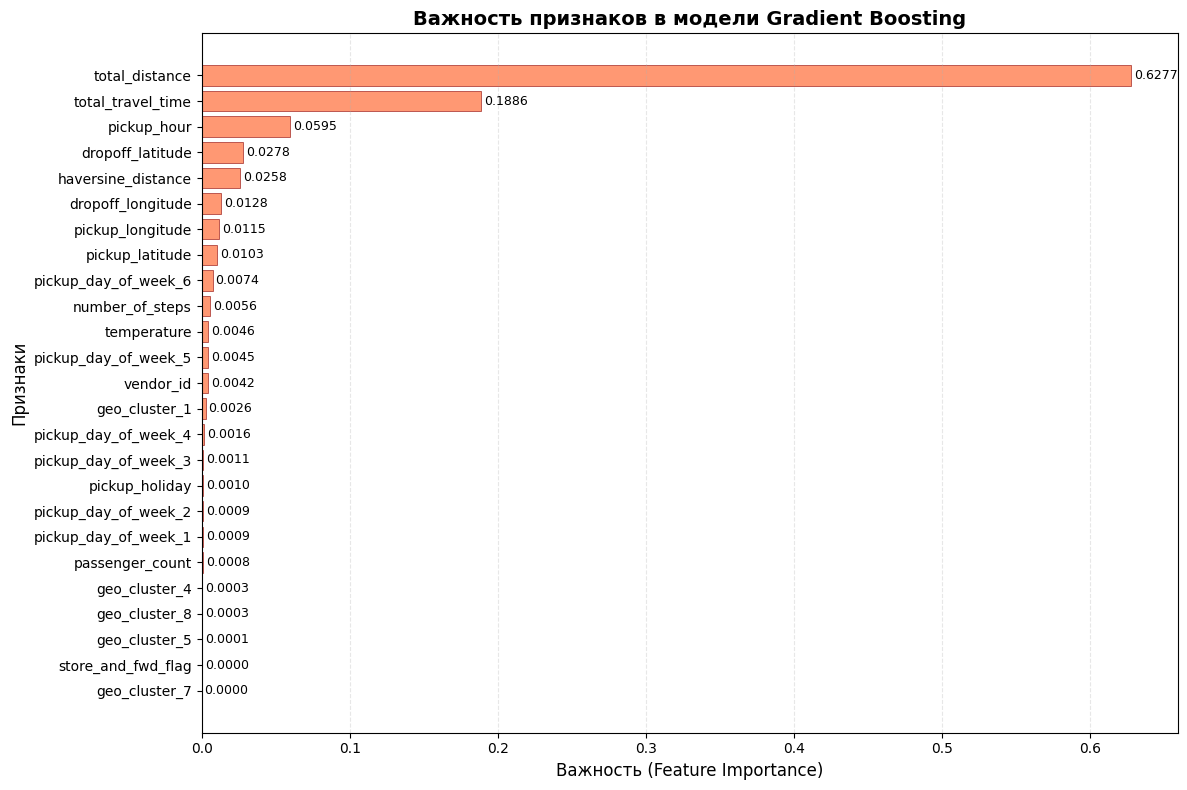

ТОП-3 НАИБОЛЕЕ ЗНАЧИМЫХ ФАКТОРА (Gradient Boosting)
1. total_distance: 0.6277 (62.77%)
2. total_travel_time: 0.1886 (18.86%)
3. pickup_hour: 0.0595 (5.95%)


In [196]:
# 1. Получаем важность признаков из модели Gradient Boosting
# Получаем значения важности
feature_importance = gb_model.feature_importances_

# Создаём DataFrame с важностью признаков
importance_df = pd.DataFrame({
    'Признак': SKB_selector_cols,
    'Важность': feature_importance
})

# Сортируем по убыванию важности
importance_df = importance_df.sort_values('Важность', ascending=False)

# 2. Столбчатая диаграмма
plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Признак'], importance_df['Важность'], 
                color='coral', alpha=0.8, edgecolor='darkred', linewidth=0.5)

plt.xlabel('Важность (Feature Importance)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Важность признаков в модели Gradient Boosting', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Добавляем значения важности на график
for bar, val in zip(bars, importance_df['Важность']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=9)

plt.gca().invert_yaxis()  # Самый важный признак сверху
plt.tight_layout()
plt.show()

# 3. Топ-3 наиболее значимых факторов
top3 = importance_df.head(3)
print("="*60)
print("ТОП-3 НАИБОЛЕЕ ЗНАЧИМЫХ ФАКТОРА (Gradient Boosting)")
print("="*60)
for i, (idx, row) in enumerate(top3.iterrows(), 1):
    print(f"{i}. {row['Признак']}: {row['Важность']:.4f} ({row['Важность']*100:.2f}%)")
print("="*60)

### Задание 6.5.
Для лучшей из построенных моделей рассчитайте медианную абсолютную ошибку (MeAE - в sklearn функция median_absolute_error) предсказания длительности поездки такси на валидационной выборке:
$$ MeAE = median(|y_i-\hat{y_i}|)$$

Значение метрики MeAE переведите в минуты и округлите до десятых.


In [197]:
# переводим вектора целевого и предсказанных значений из логарифмического в обычный вид
y_valid = np.exp(y_valid_log) - 1
y_pred_valid_gbr = np.exp(y_valid_pred_gb) - 1

# вычисляем метрику MeAE
round(metrics.median_absolute_error(y_valid, y_pred_valid_gbr) / 60, 1)

1.8

Финальный шаг - сделать submit -  предсказание для отложенного тестового набора данных. 

Прочитаем тестовые данные и заранее выделим столбец с идентификаторами поездок из тестового набора данных. Он нам еще пригодится:


In [198]:
test_data = pd.read_csv("data/Project5_test_data.csv")
osrm_data_test = pd.read_csv("data/Project5_osrm_data_test.csv")
test_id = test_data['id']

test_data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


Перед созданием прогноза для тестовой выборки необходимо произвести все манипуляции с данными, которые мы производили с тренировочной выборкой, а именно:
* Перевести признак pickup_datetime в формат datetime;
* Добавить новые признаки (временные, географические, погодные и другие факторы);
* Произвести очистку данных от пропусков;
* Произвести кодировку категориальных признаков:
    * Закодировать бинарные признаки;
    * Закодировать номинальные признаки с помощью обученного на тренировочной выборке OneHotEncoder’а;
* Сформировать матрицу наблюдений, оставив в таблице только те признаки, которые были отобраны с помощью SelectKBest;
* Нормализовать данные с помощью обученного на тренировочной выборке MinMaxScaler’а.


In [199]:
test_data['pickup_datetime']=pd.to_datetime(test_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S')

# применяем преобразования с помощью функции
test_data = add_datetime_features(test_data)
test_data = add_holiday_features(test_data, holiday_data)
test_data = add_osrm_features(test_data, osrm_data_test)
test_data = add_geographical_features(test_data)
test_data = add_cluster_features(test_data, kmeans)
test_data = add_weather_features(test_data, weather_data)
test_data = fill_null_weather_data(test_data)

# кодируем признаки
test_data['vendor_id'] = (test_data['vendor_id'] != 1).astype(int)
test_data['store_and_fwd_flag'] = test_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)
test_data['pickup_day_of_week'] = test_data['pickup_datetime'].dt.dayofweek

# список признаков для кодирования
columns_to_change_test = ['pickup_day_of_week', 'geo_cluster', 'events']

# создаём объект класса OneHotEncoder
OHE_encoder_test = preprocessing.OneHotEncoder(drop='first')

# выполняем OneHot-кодирование
test_data_onehot = OHE_encoder_test.fit_transform(test_data[columns_to_change_test]).toarray()
column_names = OHE_encoder_test.get_feature_names_out(columns_to_change_test)
test_data_onehot = pd.DataFrame(test_data_onehot, columns=column_names)

test_data = pd.concat(
    [test_data.reset_index(drop=True).drop(columns_to_change_test, axis=1), test_data_onehot], 
    axis=1
)

X_test = test_data[SKB_selector_cols]
X_test_scaled = MMS_scaler.transform(X_test)

Погодные признаки успешно добавлены. Размер таблицы: (625134, 24)
Добавлены столбцы: temperature, visibility, wind speed, precip, events


In [201]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 38 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    625134 non-null  object        
 1   vendor_id             625134 non-null  int32         
 2   pickup_datetime       625134 non-null  datetime64[ns]
 3   passenger_count       625134 non-null  int64         
 4   pickup_longitude      625134 non-null  float64       
 5   pickup_latitude       625134 non-null  float64       
 6   dropoff_longitude     625134 non-null  float64       
 7   dropoff_latitude      625134 non-null  float64       
 8   store_and_fwd_flag    625134 non-null  int64         
 9   pickup_date           625134 non-null  datetime64[ns]
 10  pickup_hour           625134 non-null  int8          
 11  pickup_holiday        625134 non-null  int8          
 12  total_distance        625134 non-null  float64       
 13 

Только после выполнения всех этих шагов можно сделать предсказание длительности поездки для тестовой выборки. Не забудьте перевести предсказания из логарифмического масштаба в истинный, используя формулу:
$$y_i=exp(z_i)-1$$

После того, как вы сформируете предсказание длительности поездок на тестовой выборке вам необходимо будет создать submission-файл в формате csv, отправить его на платформу Kaggle и посмотреть на результирующее значение метрики RMSLE на тестовой выборке.

Код для создания submission-файла:


In [202]:
y_test_pred_gbr_log = gb_model.predict(X_test_scaled)
y_test_pred = np.exp(y_test_pred_gbr_log) - 1


submission = pd.DataFrame({'id': test_id, 'trip_duration': y_test_pred})
submission.to_csv('data/submission_gb.csv', index=False)

In [203]:
print("="*50)
print("ПРЕДСКАЗАНИЕ НА ТЕСТОВОМ НАБОРЕ")
print("="*50)
print(f"Форма тестовых данных: {X_test.shape}")
print(f"Количество предсказаний: {len(y_test_pred)}")
print(f"Диапазон предсказаний: {y_test_pred.min():.2f} - {y_test_pred.max():.2f}")
print(f"Среднее предсказание: {y_test_pred.mean():.2f}")
print("="*50)

ПРЕДСКАЗАНИЕ НА ТЕСТОВОМ НАБОРЕ
Форма тестовых данных: (625134, 25)
Количество предсказаний: 625134
Диапазон предсказаний: -0.36 - 14626.55
Среднее предсказание: 808.72


### **В качестве бонуса**

В завершение по ансамблевым мы предлагаем вам попробовать улучшить свое предсказание, воспользовавшись моделью экстремального градиентного бустинга (XGBoost) из библиотеки xgboost.

**XGBoost** - современная модель машинного обучения, которая является продолжением идеи градиентного бустинга Фридмана. У нее есть несколько преимуществ по сравнению с классической моделью градиентного бустинга из библиотеки sklearn: повышенная производительность путем параллелизации процесса обучения, повышенное качество решения за счет усовершенствования алгоритма бустинга, меньшая склонность к переобучению и широкий функционал возможности управления параметрами модели.


Для ее использования необходимо для начала установить пакет xgboost:

In [ ]:
#!pip install xgboost

После чего модуль можно импортировать:

In [205]:
import xgboost as xgb

Перед обучением модели необходимо перевести наборы данных в тип данных xgboost.DMatrix:

In [206]:
# создаём матрицы наблюдений в формате DMatrix
dtrain = xgb.DMatrix(X_train_scaled, label=y_train_log, feature_names=SKB_selector_cols)
dvalid = xgb.DMatrix(X_valid_scaled, label=y_valid_log, feature_names=SKB_selector_cols)
dtest = xgb.DMatrix(X_test_scaled, feature_names=SKB_selector_cols)

Обучение модели XGBoost происходит с помощью метода train, в который необходимо передать параметры модели, набор данных, количество базовых моделей в ансамбле, а также дополнительные параметры:


In [207]:
# гиперпараметры модели
params_xgb = {
    'min_child_weight': 20, 
    'eta': 0.1, 
    'colsample_bytree': 0.9, 
    'max_depth': 6, 
    'subsample': 0.9, 
    'lambda': 1, 
    'nthread': -1, 
    'booster': 'gbtree', 
    'eval_metric': 'rmse', 
    'objective': 'reg:squarederror'
}

# тренировочная и валидационная выборка
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# обучаем модель XGBoost
XGB = xgb.train(
    params=params_xgb,          # гиперпараметры модели
    dtrain=dtrain,              # обучающая выборка
    num_boost_round=300,        # количество моделей в ансамбле
    evals=watchlist,            # выборки, на которых считается матрица
    early_stopping_rounds=20,   # раняя остановка
    maximize=False,             # смена поиска максимума на минимум
    verbose_eval=25             # шаг, через который происходит отображение метрик
)

[0]	train-rmse:0.73991	valid-rmse:0.74193
[25]	train-rmse:0.43199	valid-rmse:0.43497
[50]	train-rmse:0.41335	valid-rmse:0.41685
[75]	train-rmse:0.40429	valid-rmse:0.40865
[100]	train-rmse:0.39938	valid-rmse:0.40455
[125]	train-rmse:0.39643	valid-rmse:0.40224
[150]	train-rmse:0.39383	valid-rmse:0.40021
[175]	train-rmse:0.39150	valid-rmse:0.39856
[200]	train-rmse:0.38953	valid-rmse:0.39741
[225]	train-rmse:0.38783	valid-rmse:0.39639
[250]	train-rmse:0.38647	valid-rmse:0.39589
[275]	train-rmse:0.38530	valid-rmse:0.39525
[299]	train-rmse:0.38410	valid-rmse:0.39467


Предсказать целевой признак на новых данных можно с помощью метода predict():

In [208]:
# выполняем предсказание на тестовом наборе данных
y_test_pred_xgb = np.exp(XGB.predict(dtest)) - 1
print(f'XGB test RMSLE {XGB.best_score:.{5}f}')

XGB test RMSLE 0.39467


Также как и все модели, основанные на использовании деревьев решений в качестве базовых моделей, XGBoost имеет возможность определения коэффициентов важности факторов. Более того, в библиотеку встроена возможность визуализации важность факторов в виде столбчатой диаграммы. За эту возможность отвечает функция plot_importance():


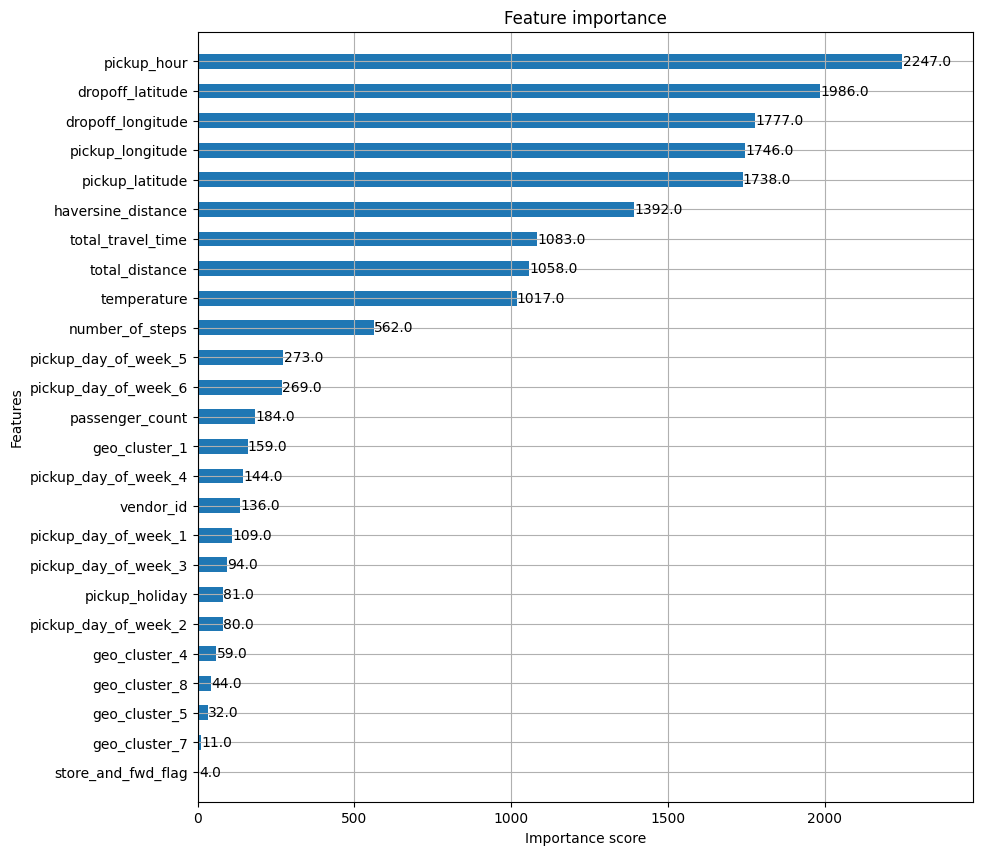

In [209]:
fig, ax_xgb = plt.subplots(figsize = (10, 10))
xgb.plot_importance(booster=XGB, ax=ax_xgb, height=0.5);